In [1]:
import itertools as IT
import time
from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gammaln

import residual_consensus as rc   # the updated metric (self-tests run on import)

RNG = np.random.default_rng(7)    # one seeded generator for the whole study
sns.set_theme(style="whitegrid", context="notebook")

## Functions: exhaustive cloud + baseline + residual for a whole (N, K)

In [2]:
def enumerate_compositions_fast(n, k):
    '''All count-vectors summing to n over k categories (vectorized bars-and-stars).'''
    if k == 1:
        return np.array([[n]], dtype=np.int64)
    idx = np.array(list(IT.combinations(range(n + k - 1), k - 1)), dtype=np.int64)
    edges = np.hstack([np.full((idx.shape[0], 1), -1, dtype=np.int64),
                       idx,
                       np.full((idx.shape[0], 1), n + k - 1, dtype=np.int64)])
    return np.diff(edges, axis=1) - 1


def baseline_curve(A, mean, window=rc.WINDOW, min_pts=40):
    '''E, Q1, Q3, IQR on the 0.01-rounded mean grid, from a cloud of (A, mean).
       Same conventions as rc.feasible_baseline (window ±0.05, >=40 points,
       cache key rounded to 2 dp).'''
    order = np.argsort(mean)
    m_s, A_s = mean[order], A[order]
    curve = {}
    for m in np.unique(np.round(mean, 2)):
        lo = np.searchsorted(m_s, m - window, side="left")
        hi = np.searchsorted(m_s, m + window, side="right")
        sel = A_s[lo:hi]
        if sel.size < min_pts:
            curve[m] = (np.nan, np.nan, np.nan, np.nan)
        else:
            q1, q3 = np.percentile(sel, [25, 75])
            curve[m] = (float(sel.mean()), float(q1), float(q3), float(q3 - q1))
    return curve


def get_residual_df(n, k, use_mc=None, mc_samples=rc.MC_SAMPLES, rng=RNG):
    '''The updated-metric analogue of the old get_df(): one row per composition with
       Agreement (A), mean, median, std_dev  +  E, Q1, Q3, IQR_band, z, defined.'''
    t0 = time.time()
    total = comb(n + k - 1, k - 1)
    if use_mc is None:
        use_mc = total > rc.ENUM_CAP          # mirror the module's switch
    if use_mc:
        C = rc._random_compositions(n, k, mc_samples, rng)
        how = f"Monte-Carlo {mc_samples:,} draws (exact cloud = {total:,} > ENUM_CAP)"
    else:
        C = enumerate_compositions_fast(n, k)
        how = f"exact enumeration, {total:,} compositions"
    A, mean = rc._A_vec(C, k)
    VALS = np.arange(k)
    p = C / n
    std = np.sqrt((p * (VALS[None, :] - mean[:, None]) ** 2).sum(axis=1))
    cum = C.cumsum(axis=1)
    med = (VALS[(cum > (n - 1) // 2).argmax(axis=1)] + VALS[(cum > n // 2).argmax(axis=1)]) / 2.0

    base = baseline_curve(A, mean)
    EQ = np.array([base[m] for m in np.round(mean, 2)])
    E, Q1, Q3, IQR = EQ.T
    with np.errstate(invalid="ignore", divide="ignore"):
        z = np.where(np.isfinite(IQR) & (IQR > rc.EPS), (A - E) / IQR, np.nan)
    df = pd.DataFrame({"Agreement": A, "mean": mean, "median": med, "std_dev": std,
                       "E": E, "Q1": Q1, "Q3": Q3, "IQR_band": IQR,
                       "z": z, "defined": np.isfinite(z)})
    print(f"N={n}, K={k}: {how}  ({time.time()-t0:.1f}s)  "
          f"defined: {100*df['defined'].mean():.1f}%")
    return df, base

In [3]:
BLUE, BAND_C = "#1f5fa8", "#a9c9e8"
RED, GREEN, GREY = "#b3401e", "#1a7a4a", "#666666"
DOT_GRAY = "#808080"

def quantile_band(df, qlo=5, qhi=95, step=0.02, window=rc.WINDOW, min_pts=40):
    '''Centerline E[A|mu] and (qlo, qhi) feasible band on a fine mean grid.'''
    mean = df["mean"].to_numpy(); A = df["Agreement"].to_numpy()
    order = np.argsort(mean); m_s, A_s = mean[order], A[order]
    grid = np.arange(m_s[0], m_s[-1] + step / 2, step)
    E = np.full(grid.size, np.nan); lo = E.copy(); hi = E.copy()
    for i, m in enumerate(grid):
        a = np.searchsorted(m_s, m - window, "left")
        b = np.searchsorted(m_s, m + window, "right")
        sel = A_s[a:b]
        if sel.size >= min_pts:
            E[i] = sel.mean(); lo[i], hi[i] = np.percentile(sel, [qlo, qhi])
    ok = np.isfinite(E)
    return grid[ok], E[ok], lo[ok], hi[ok]


def band_figure(df, base, n, k, max_pts=40_000, rng=RNG):
    '''Residual vs mean rating for the whole composition cloud, in the uniform
       residual-encoding design (flattened baseline at 0, light-blue feasible band).
       Left: raw residual A - E[A|mu]. Right: standardized residual z.
       Every composition is a gray dot (subsampled above max_pts).'''
    grid, E, lo, hi = quantile_band(df)
    d = df[df["defined"]]
    shown = ""
    if len(d) > max_pts:
        d = d.iloc[rng.choice(len(d), max_pts, replace=False)]
        shown = f"  ({max_pts:,} shown of {int(df['defined'].sum()):,})"
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle(f"N={n}, K={k}: residual vs mean rating   |   "
                 f"gray dots = compositions{shown}", fontsize=13)

    ax = axes[0]
    ax.fill_between(grid, lo - E, hi - E, color=BAND_C, alpha=0.45, lw=0)
    ax.scatter(d["mean"], d["Agreement"] - d["E"], s=5, color=DOT_GRAY,
               alpha=0.55, lw=0, zorder=3)
    ax.plot(grid, np.zeros_like(grid), color=BLUE, lw=2.2, zorder=4)
    ax.set(xlabel=f"mean rating  mu  (0-{k-1} scale)",
           ylabel="residual  A - E[A|mu]",
           title="raw residual (flattened baseline, 5-95% band)")

    ax = axes[1]
    ax.scatter(d["mean"], d["z"], s=5, color=DOT_GRAY, alpha=0.55, lw=0, zorder=3)
    ax.axhline(0, color=BLUE, lw=2.2, zorder=4)
    ax.set(xlabel=f"mean rating  mu  (0-{k-1} scale)",
           ylabel="residual consensus  z",
           title="standardized residual  z = (A - E) / IQR")

    for ax in axes:
        ax.set_xlim(0, k - 1)
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()


def diagnostics_figure(df, n, k, max_pts=30_000, rng=RNG):
    '''2x3 diagnostics. Top row: standardized residual z — distribution,
       z vs median, z vs std_dev. Bottom row: raw residual A - E[A|mu] —
       distribution, residual vs median, residual vs std_dev.
       Gray dots = compositions (subsampled above max_pts); medians are
       horizontally jittered to reveal density at the discrete values.'''
    d = df[df["defined"]]
    if len(d) > max_pts:
        d = d.iloc[rng.choice(len(d), max_pts, replace=False)]
    res = (d["Agreement"] - d["E"]).to_numpy()
    med_j = d["median"].to_numpy() + rng.uniform(-0.08, 0.08, len(d))

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"N={n}, K={k}: residual diagnostics   |   gray dots = compositions",
                 fontsize=13)

    axes[0, 0].hist(d["z"], bins=60, color="steelblue")
    axes[0, 0].set(xlabel="z", title="distribution of z")
    axes[0, 1].scatter(med_j, d["z"], s=5, color=DOT_GRAY, alpha=0.5, lw=0, zorder=3)
    axes[0, 1].axhline(0, color=BLUE, lw=1.8, zorder=4)
    axes[0, 1].set(xlabel="median (jittered)", ylabel="z", title="z vs median")
    axes[0, 2].scatter(d["std_dev"], d["z"], s=5, color=DOT_GRAY, alpha=0.5, lw=0, zorder=3)
    axes[0, 2].axhline(0, color=BLUE, lw=1.8, zorder=4)
    axes[0, 2].set(xlabel="std_dev", ylabel="z", title="z vs std_dev")

    axes[1, 0].hist(res, bins=60, color="steelblue")
    axes[1, 0].set(xlabel="A - E[A|mu]", title="distribution of residual")
    axes[1, 1].scatter(med_j, res, s=5, color=DOT_GRAY, alpha=0.5, lw=0, zorder=3)
    axes[1, 1].axhline(0, color=BLUE, lw=1.8, zorder=4)
    axes[1, 1].set(xlabel="median (jittered)", ylabel="residual  A - E[A|mu]",
                   title="residual vs median")
    axes[1, 2].scatter(d["std_dev"], res, s=5, color=DOT_GRAY, alpha=0.5, lw=0, zorder=3)
    axes[1, 2].axhline(0, color=BLUE, lw=1.8, zorder=4)
    axes[1, 2].set(xlabel="std_dev", ylabel="residual  A - E[A|mu]",
                   title="residual vs std_dev")

    for ax in axes.ravel():
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()


def summarize(df, n, k):
    d = df[df["defined"]]
    return {"N": n, "K": k, "cloud_size": len(df), "pct_defined": round(100 * df["defined"].mean(), 1),
            "corr(mean, A)": round(np.corrcoef(d["mean"], d["Agreement"])[0, 1], 3),
            "corr(mean, z)": round(np.corrcoef(d["mean"], d["z"])[0, 1], 3),
            "median(z)": round(d["z"].median(), 3), "IQR(z)": round(d["z"].quantile(.75) - d["z"].quantile(.25), 3)}

STUDY = {}   # (n, k) -> (df, baseline)
SUMMARY = []

## Full grid: N ∈ {20, 30, 50, 70} × K ∈ {4, 5, 6, 7}
Each cell shows the residual-vs-mean figure and the residual diagnostics
(residual and z against the median and against std_dev). Cells whose exact
cloud exceeds the module's `ENUM_CAP` — (30,7), (50,6), (50,7), (70,5), (70,6),
(70,7) — use its uniform-simplex Monte-Carlo sampler, exactly as
`feasible_baseline` does; each section's printout states which path was used.

### N=20, K=4

N=20, K=4: exact enumeration, 1,771 compositions  (0.0s)  defined: 93.1%


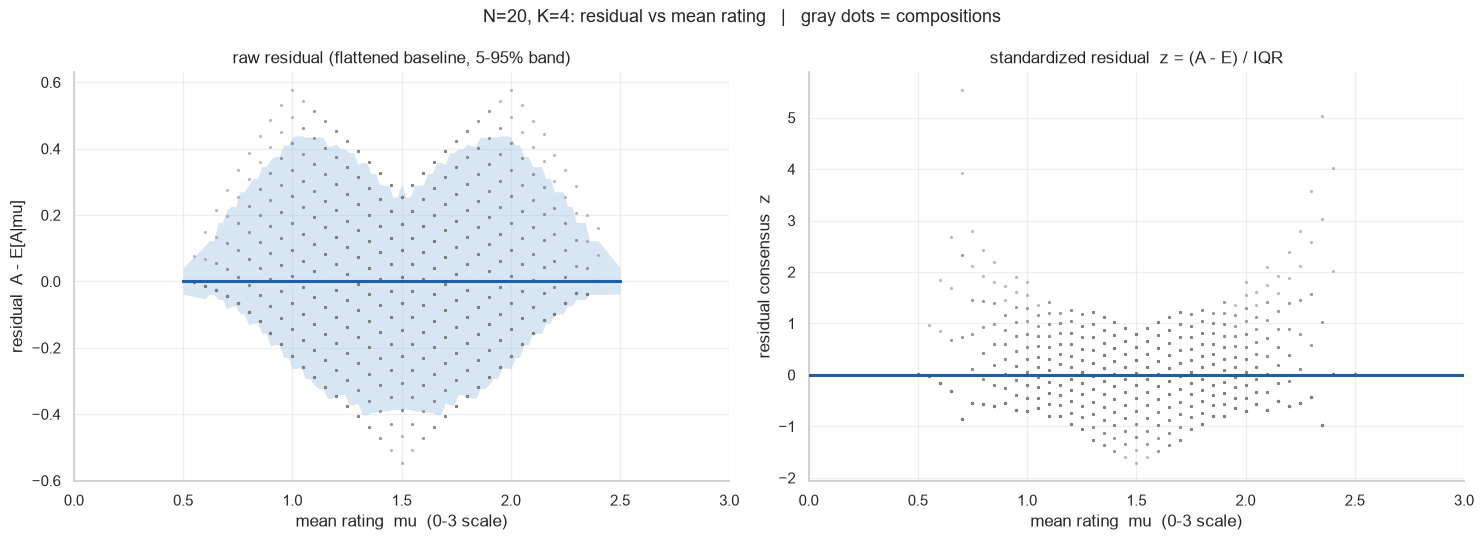

In [4]:
df, base = get_residual_df(20, 4)
STUDY[(20, 4)] = (df, base)
SUMMARY.append(summarize(df, 20, 4))
band_figure(df, base, 20, 4)

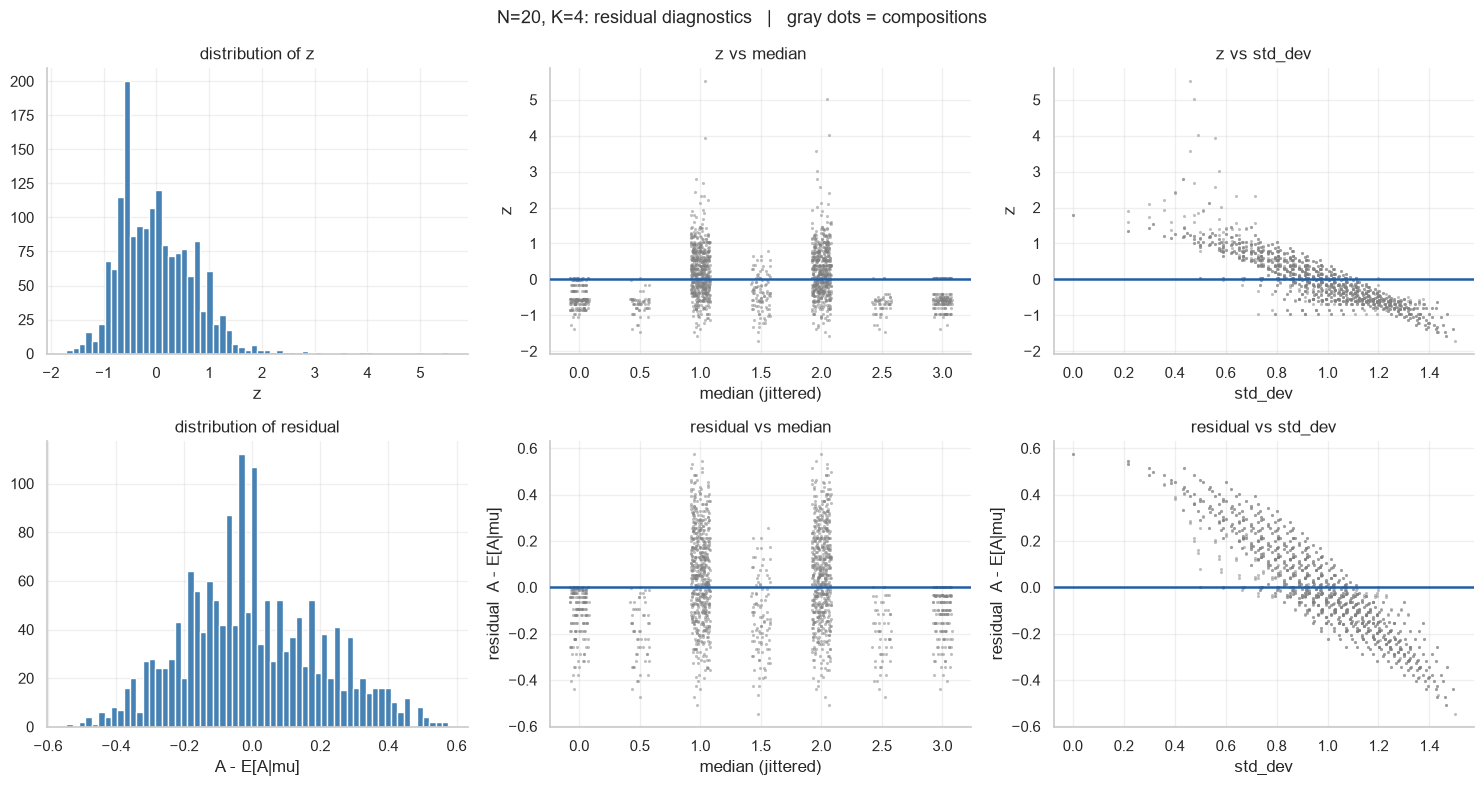

In [5]:
diagnostics_figure(df, 20, 4)

### N=20, K=5

N=20, K=5: exact enumeration, 10,626 compositions  (0.0s)  defined: 99.0%


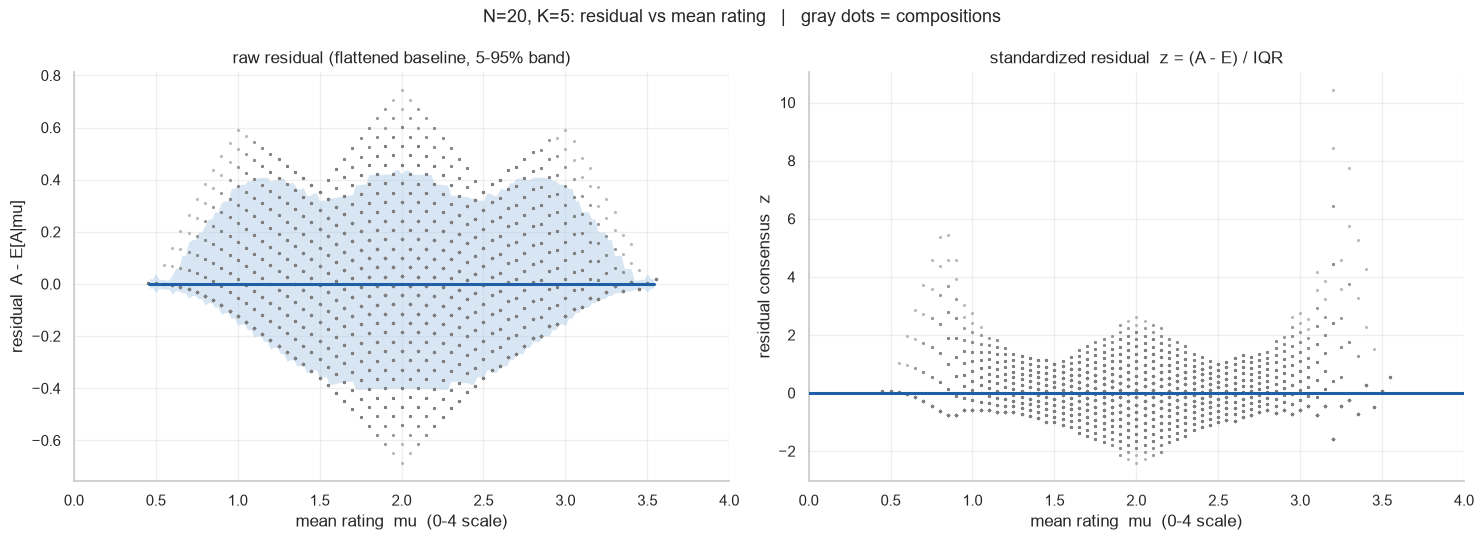

In [6]:
df, base = get_residual_df(20, 5)
STUDY[(20, 5)] = (df, base)
SUMMARY.append(summarize(df, 20, 5))
band_figure(df, base, 20, 5)

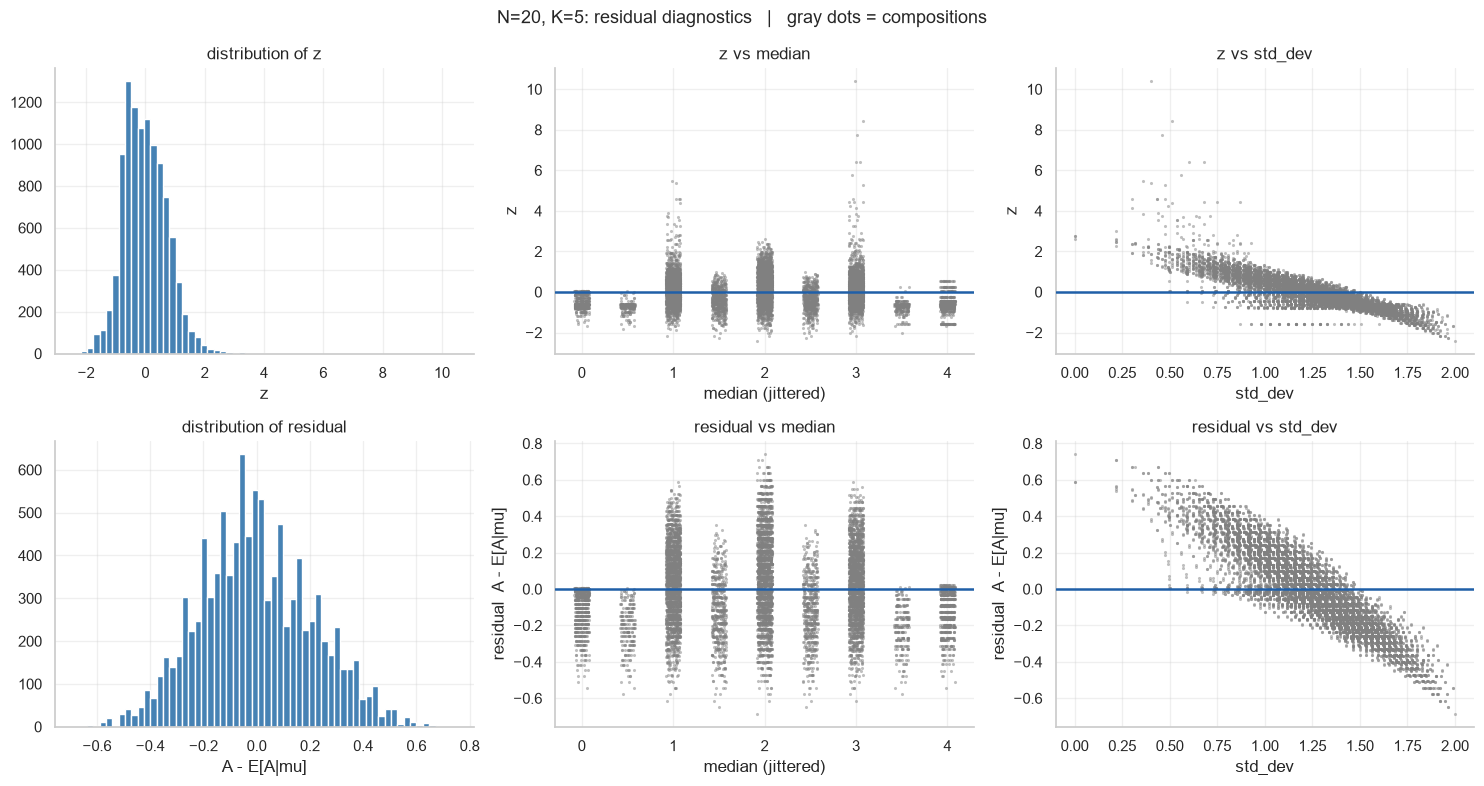

In [7]:
diagnostics_figure(df, 20, 5)

### N=20, K=6

N=20, K=6: exact enumeration, 53,130 compositions  (0.0s)  defined: 99.8%


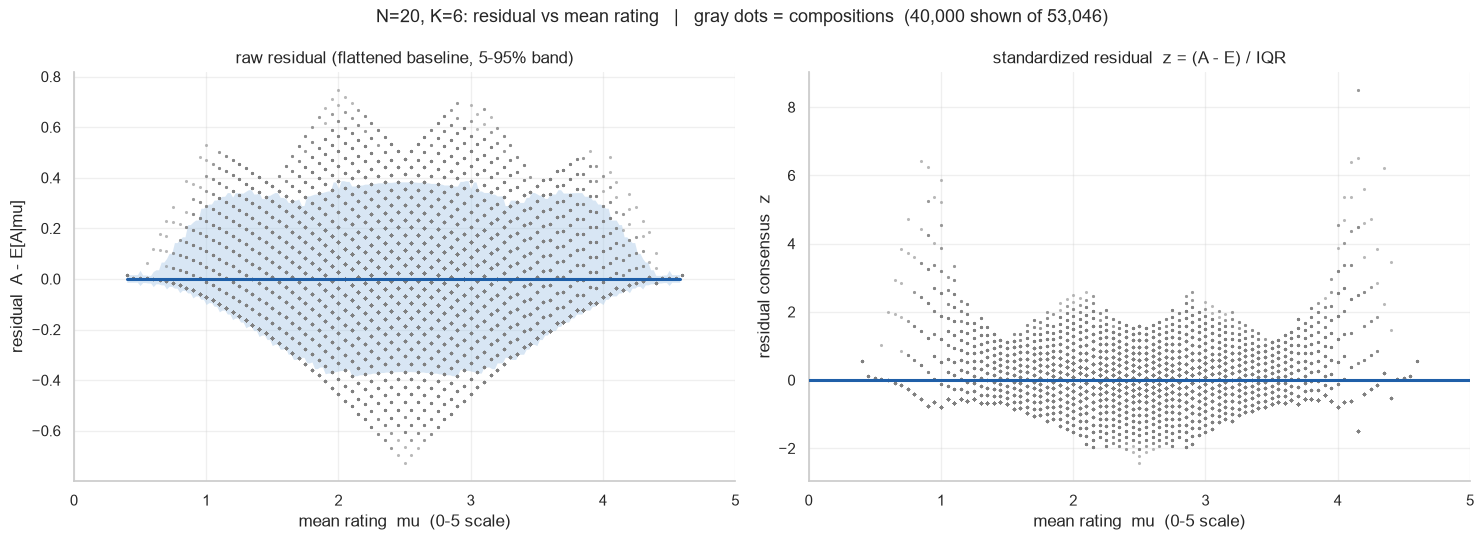

In [8]:
df, base = get_residual_df(20, 6)
STUDY[(20, 6)] = (df, base)
SUMMARY.append(summarize(df, 20, 6))
band_figure(df, base, 20, 6)

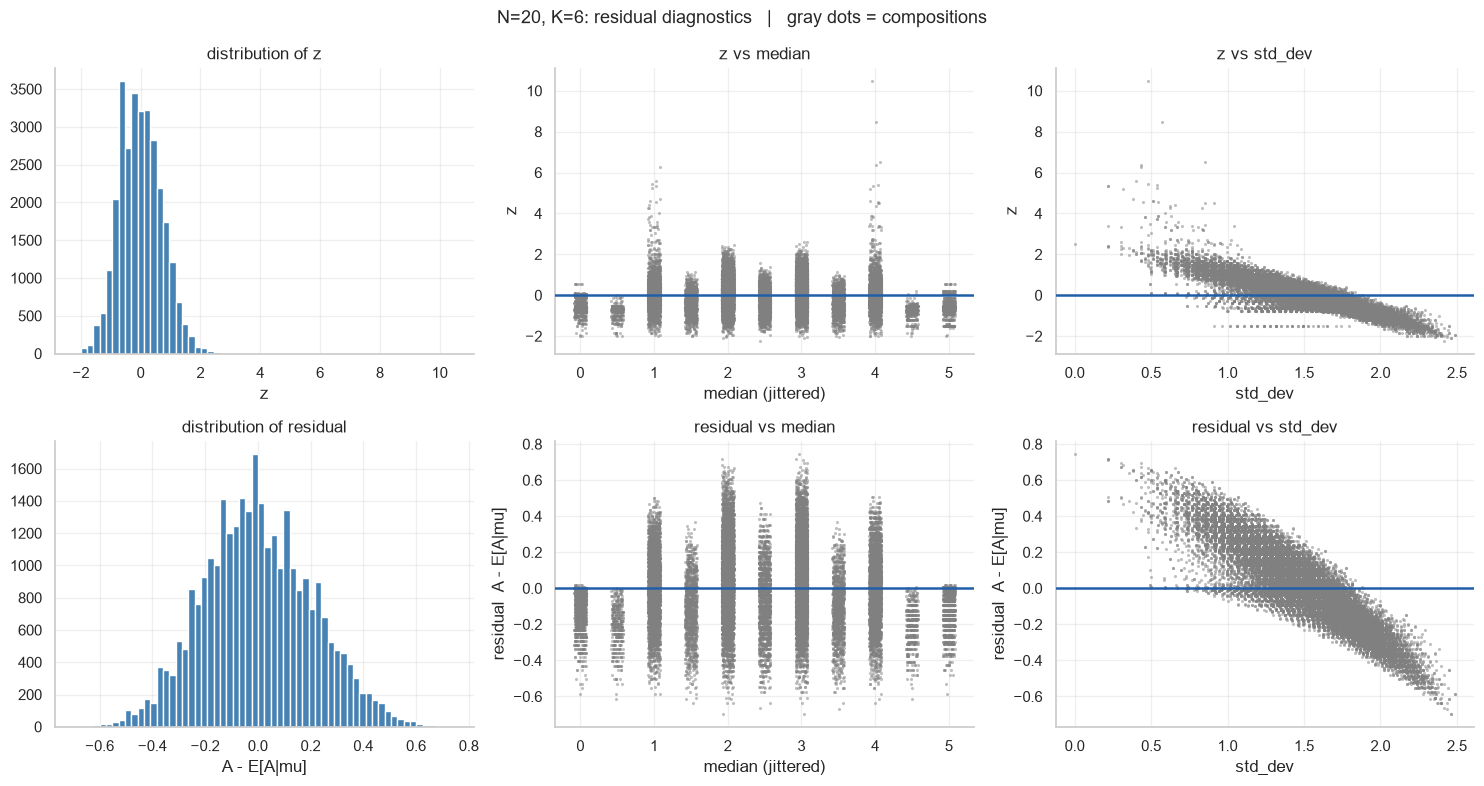

In [9]:
diagnostics_figure(df, 20, 6)

### N=20, K=7

N=20, K=7: exact enumeration, 230,230 compositions  (0.2s)  defined: 100.0%


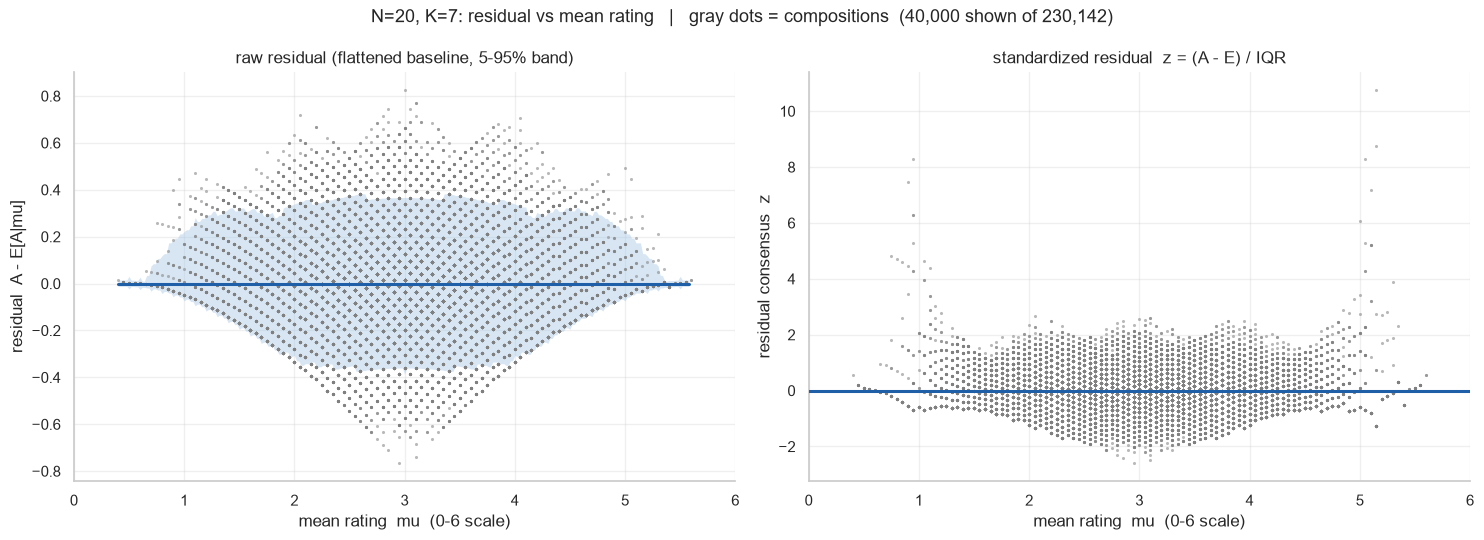

In [10]:
df, base = get_residual_df(20, 7)
STUDY[(20, 7)] = (df, base)
SUMMARY.append(summarize(df, 20, 7))
band_figure(df, base, 20, 7)

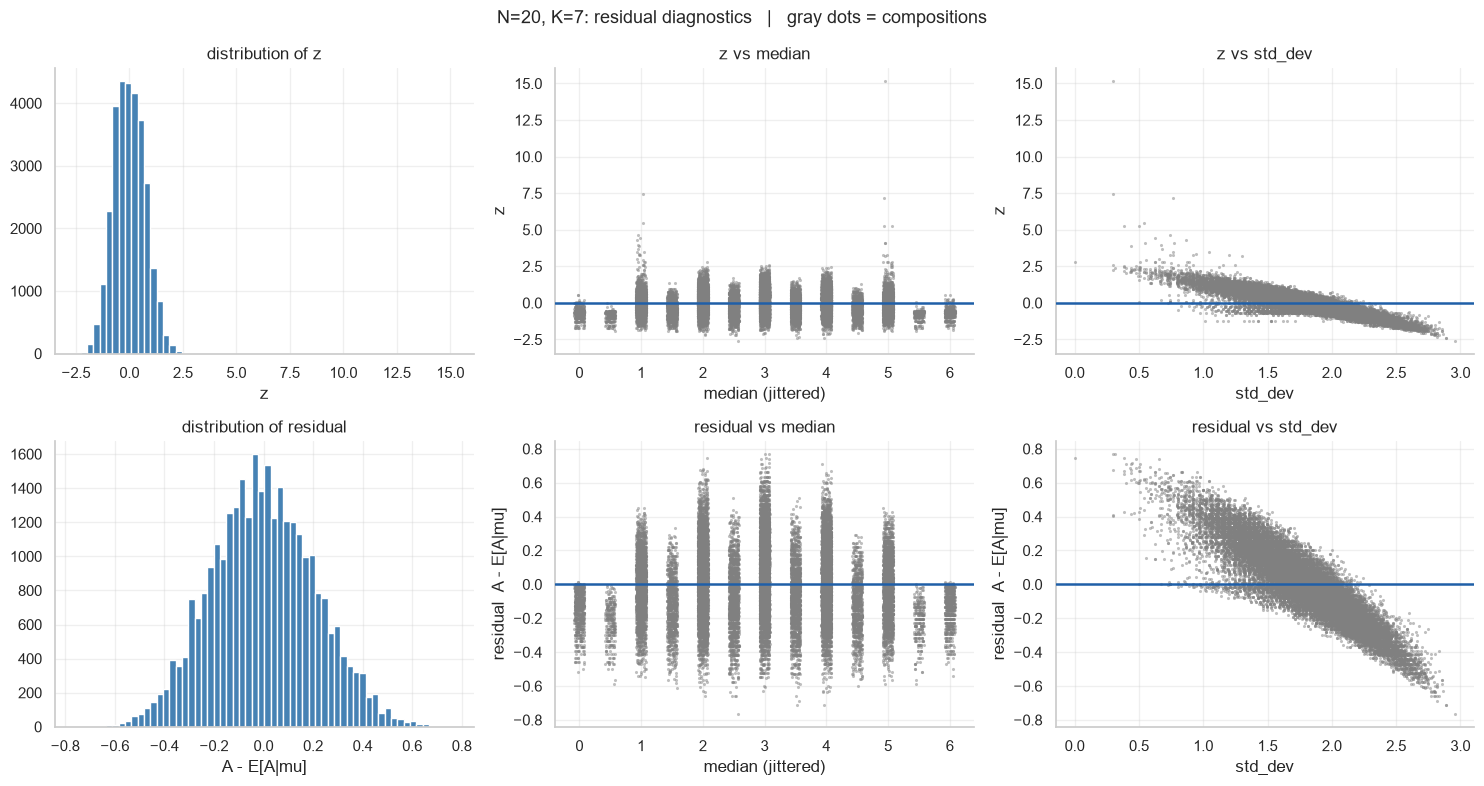

In [11]:
diagnostics_figure(df, 20, 7)

### N=30, K=4

N=30, K=4: exact enumeration, 5,456 compositions  (0.0s)  defined: 98.1%


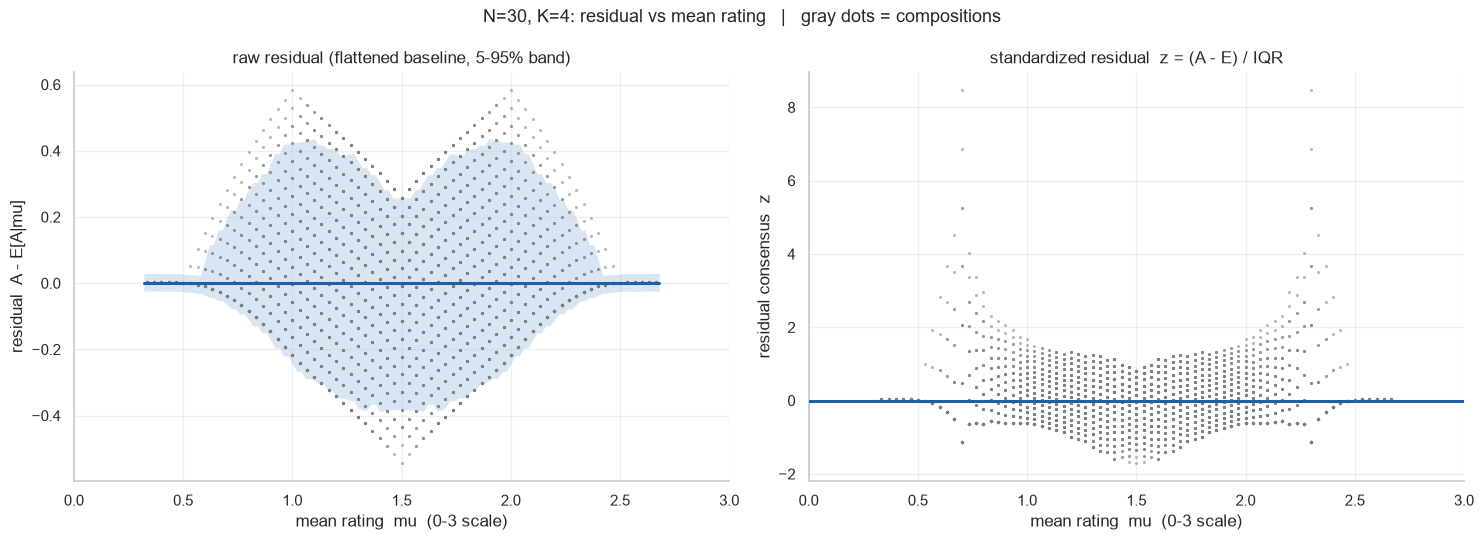

In [12]:
df, base = get_residual_df(30, 4)
STUDY[(30, 4)] = (df, base)
SUMMARY.append(summarize(df, 30, 4))
band_figure(df, base, 30, 4)

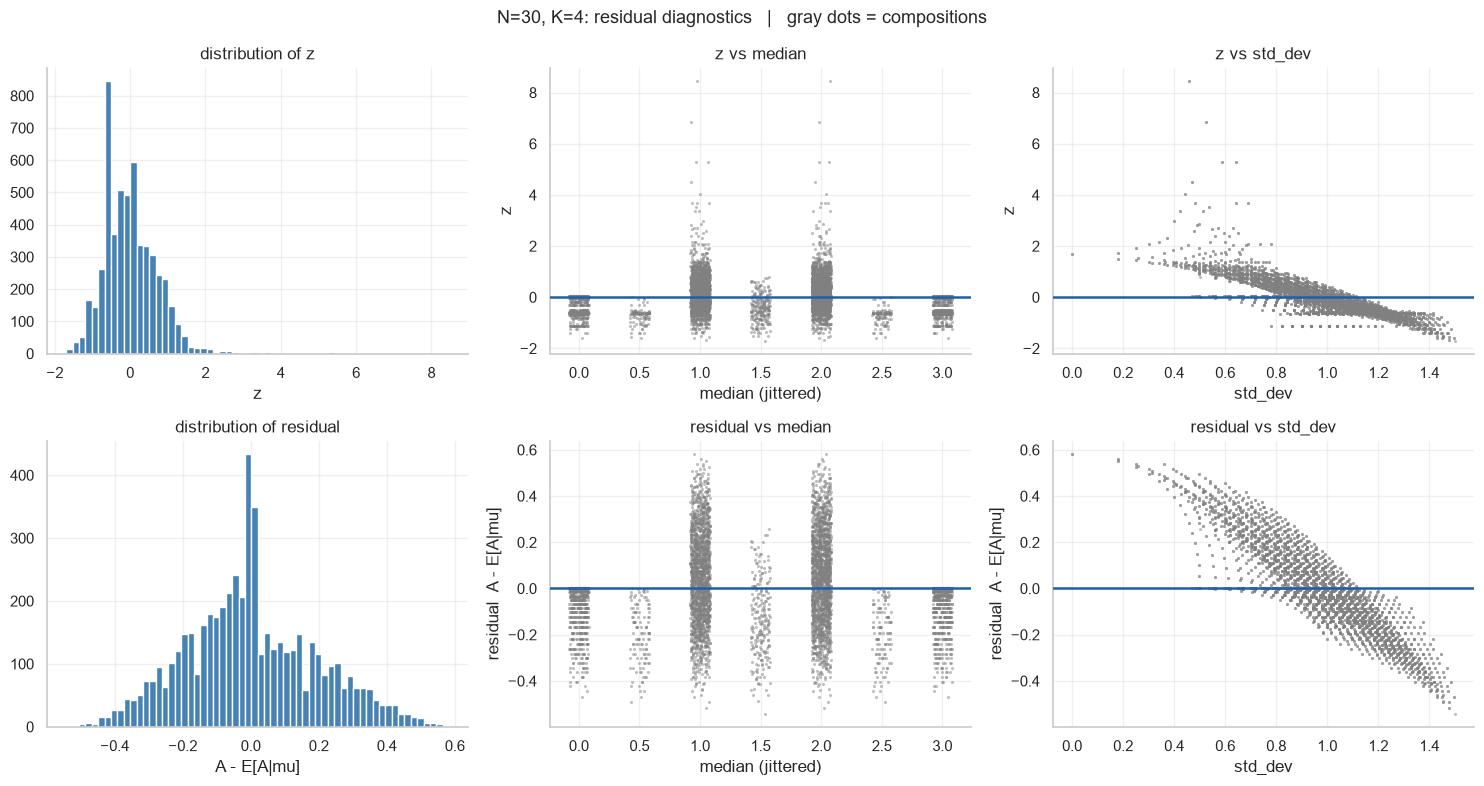

In [13]:
diagnostics_figure(df, 30, 4)

### N=30, K=5

N=30, K=5: exact enumeration, 46,376 compositions  (0.0s)  defined: 99.8%


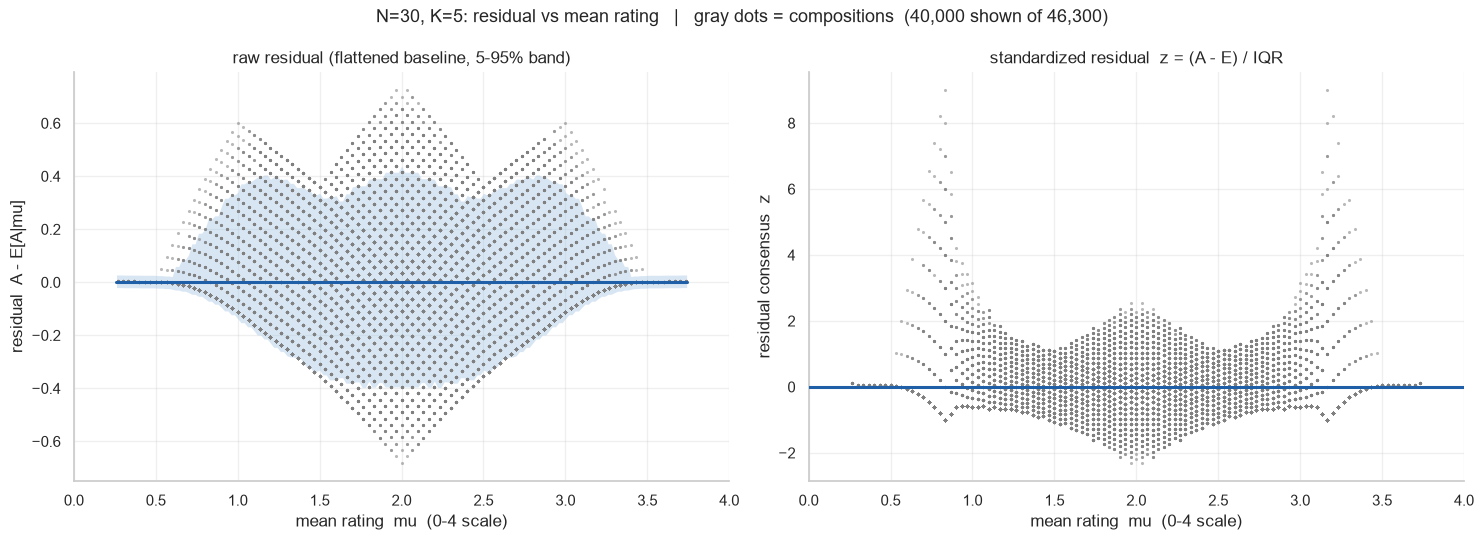

In [14]:
df, base = get_residual_df(30, 5)
STUDY[(30, 5)] = (df, base)
SUMMARY.append(summarize(df, 30, 5))
band_figure(df, base, 30, 5)

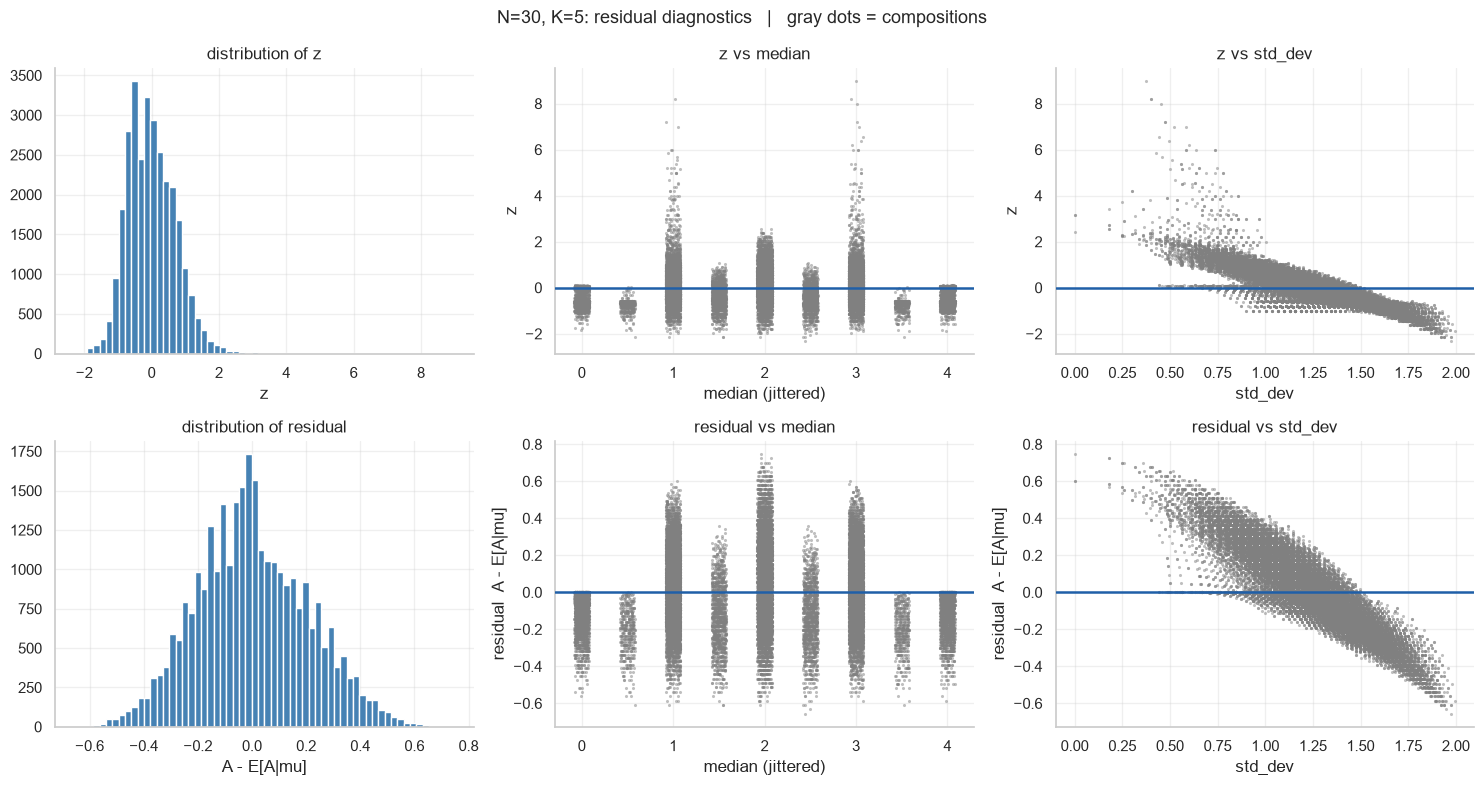

In [15]:
diagnostics_figure(df, 30, 5)

### N=30, K=6

N=30, K=6: exact enumeration, 324,632 compositions  (0.3s)  defined: 100.0%


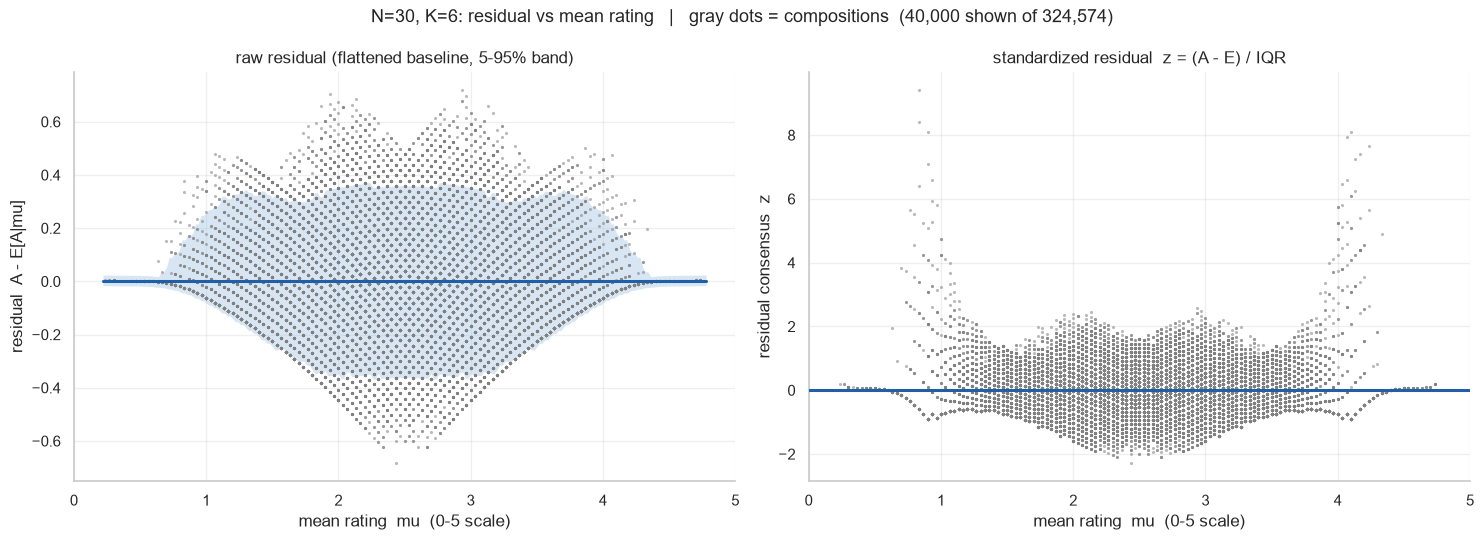

In [16]:
df, base = get_residual_df(30, 6)
STUDY[(30, 6)] = (df, base)
SUMMARY.append(summarize(df, 30, 6))
band_figure(df, base, 30, 6)

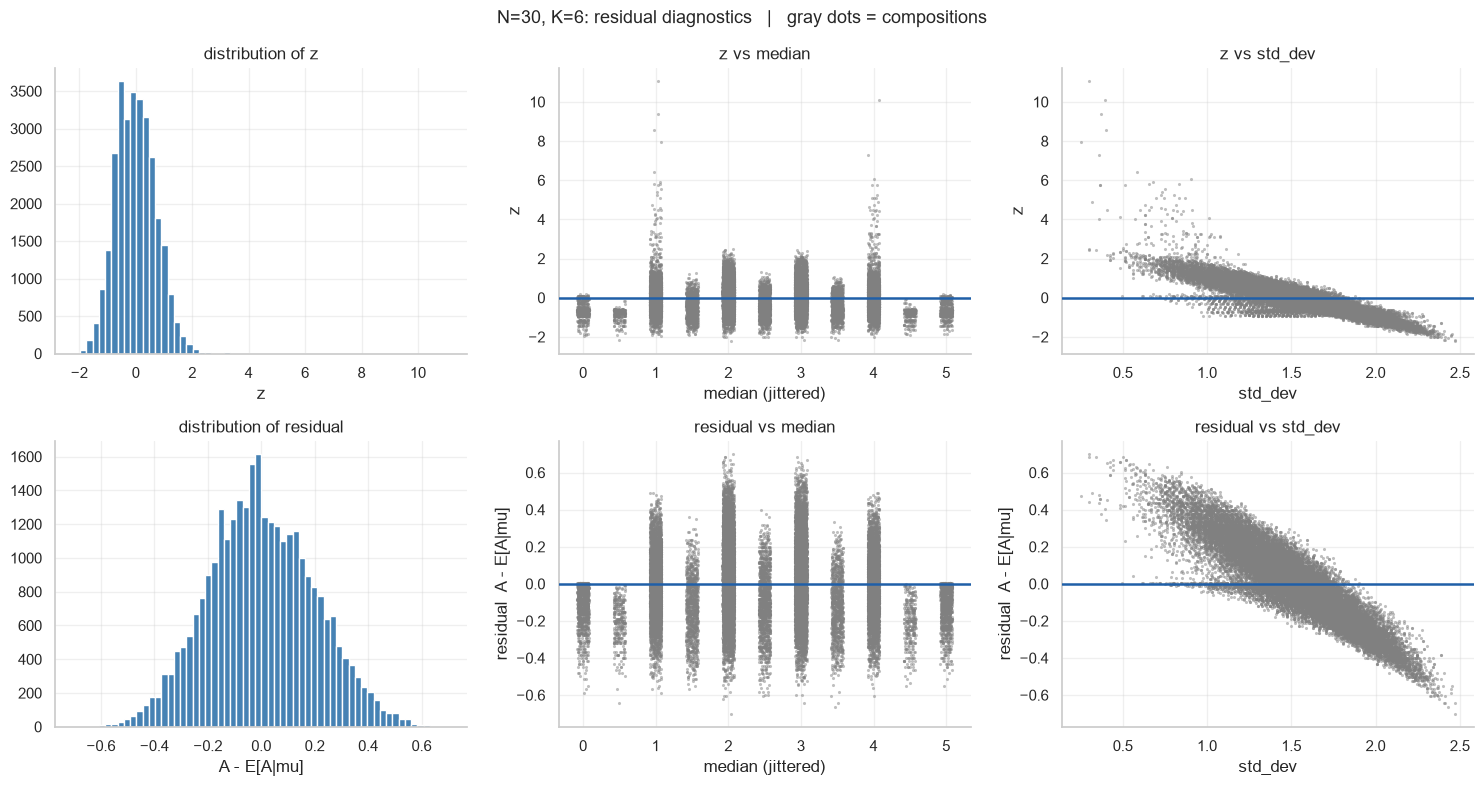

In [17]:
diagnostics_figure(df, 30, 6)

### N=30, K=7

N=30, K=7: Monte-Carlo 400,000 draws (exact cloud = 1,947,792 > ENUM_CAP)  (0.5s)  defined: 100.0%


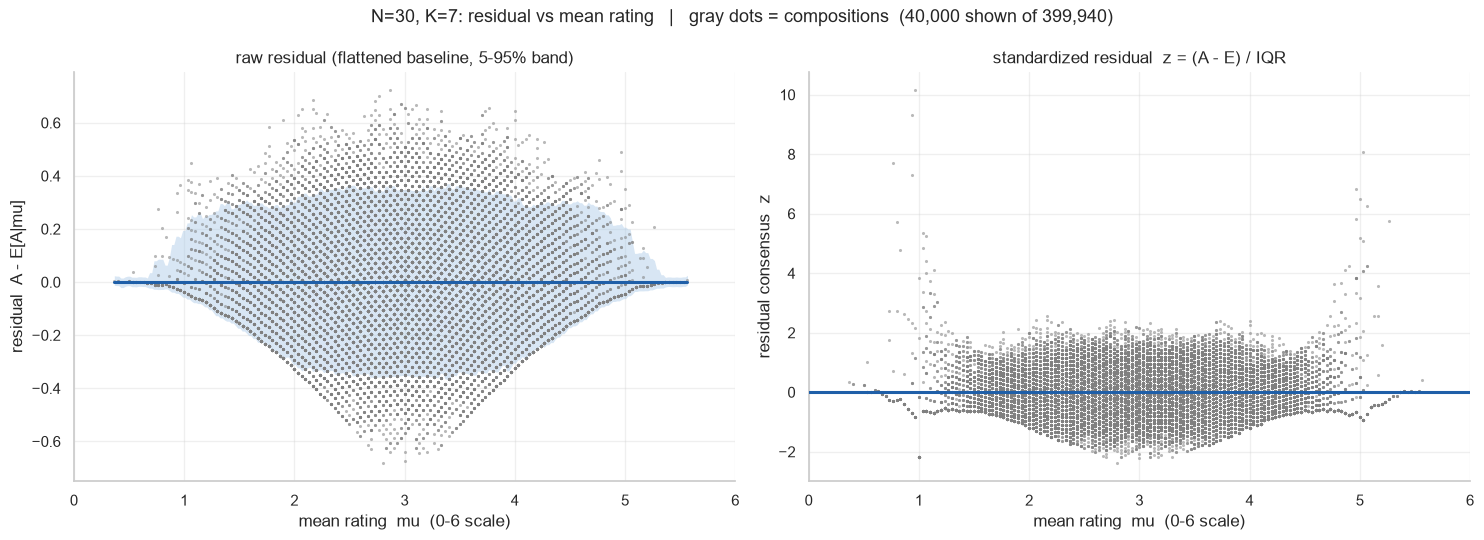

In [18]:
df, base = get_residual_df(30, 7)
STUDY[(30, 7)] = (df, base)
SUMMARY.append(summarize(df, 30, 7))
band_figure(df, base, 30, 7)

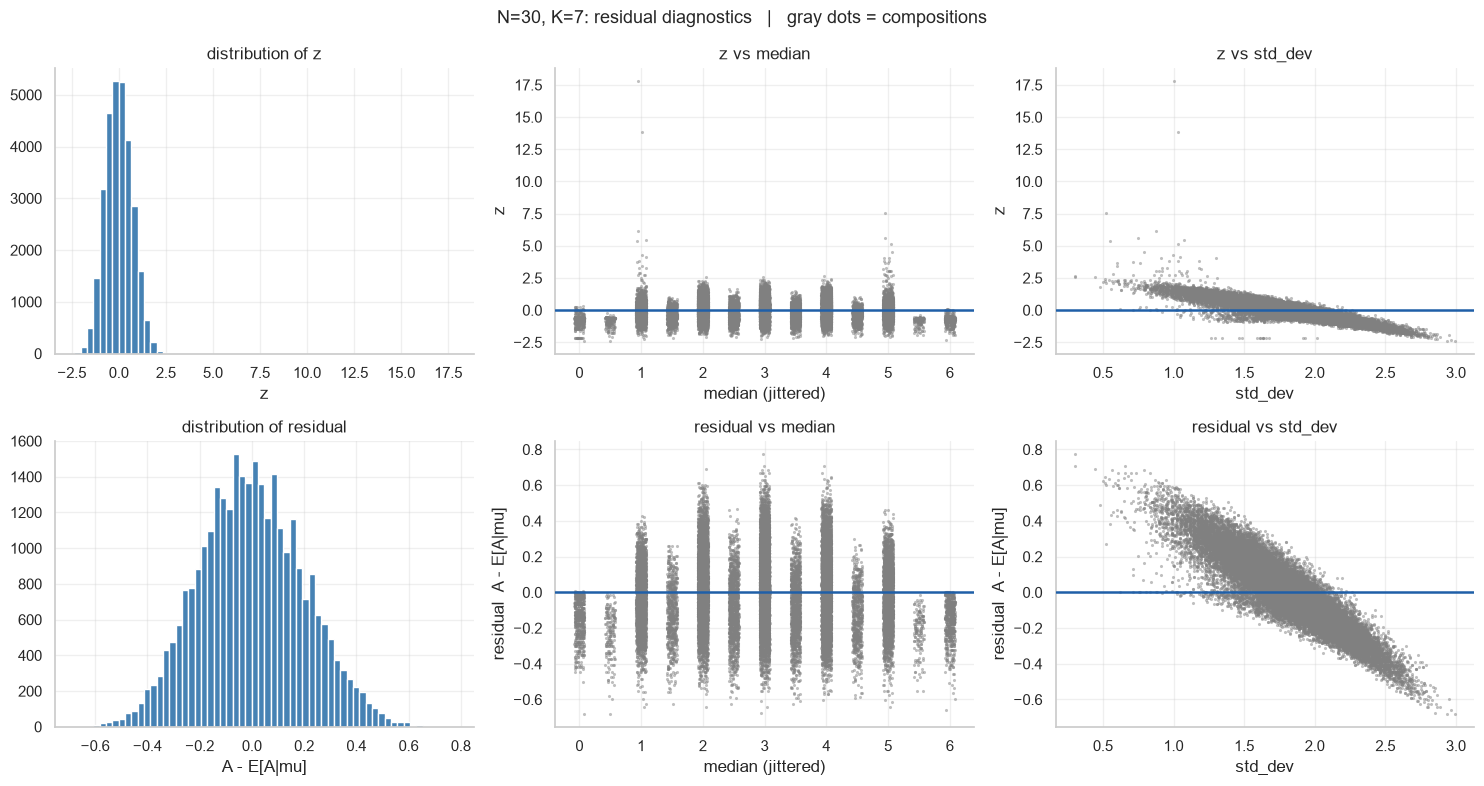

In [19]:
diagnostics_figure(df, 30, 7)

### N=50, K=4

N=50, K=4: exact enumeration, 23,426 compositions  (0.0s)  defined: 99.8%


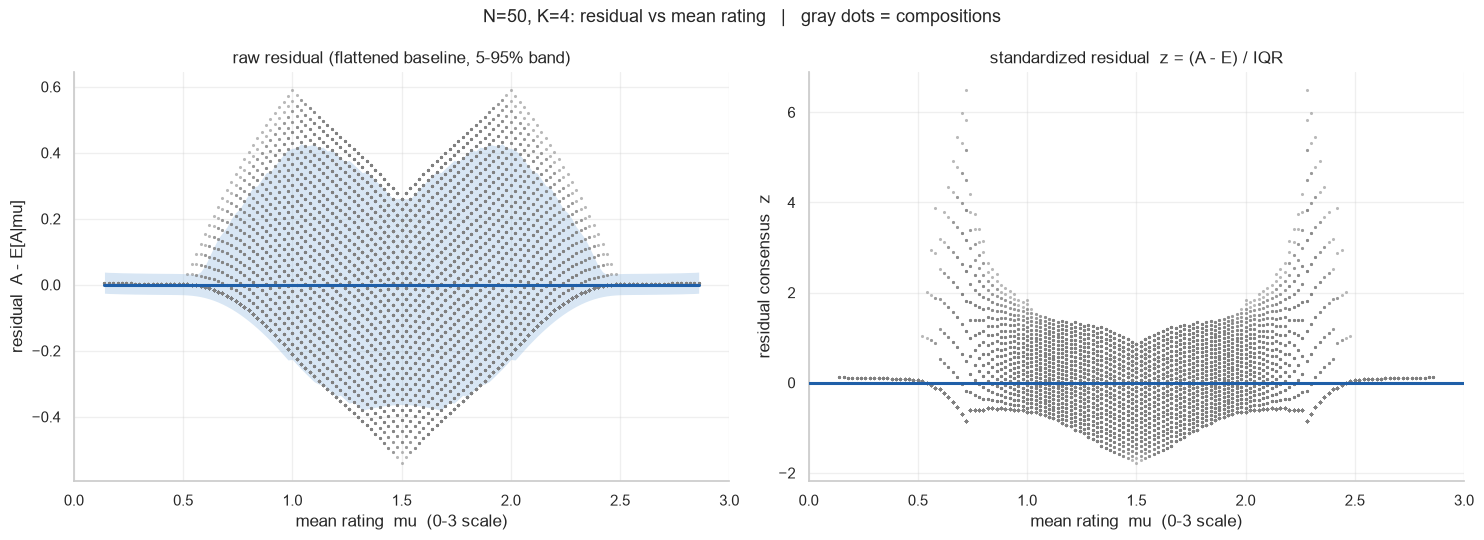

In [20]:
df, base = get_residual_df(50, 4)
STUDY[(50, 4)] = (df, base)
SUMMARY.append(summarize(df, 50, 4))
band_figure(df, base, 50, 4)

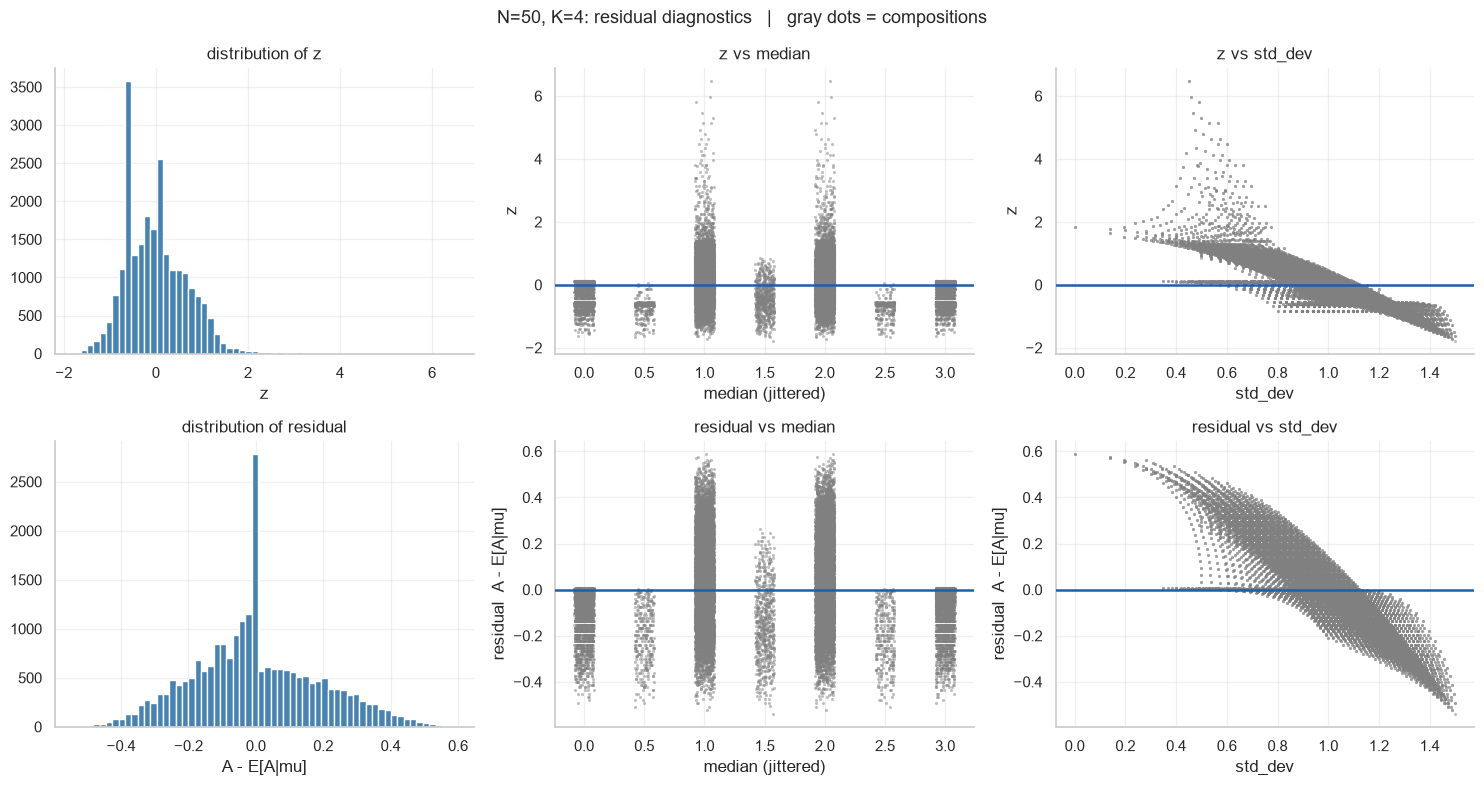

In [21]:
diagnostics_figure(df, 50, 4)

### N=50, K=5

N=50, K=5: exact enumeration, 316,251 compositions  (0.4s)  defined: 100.0%


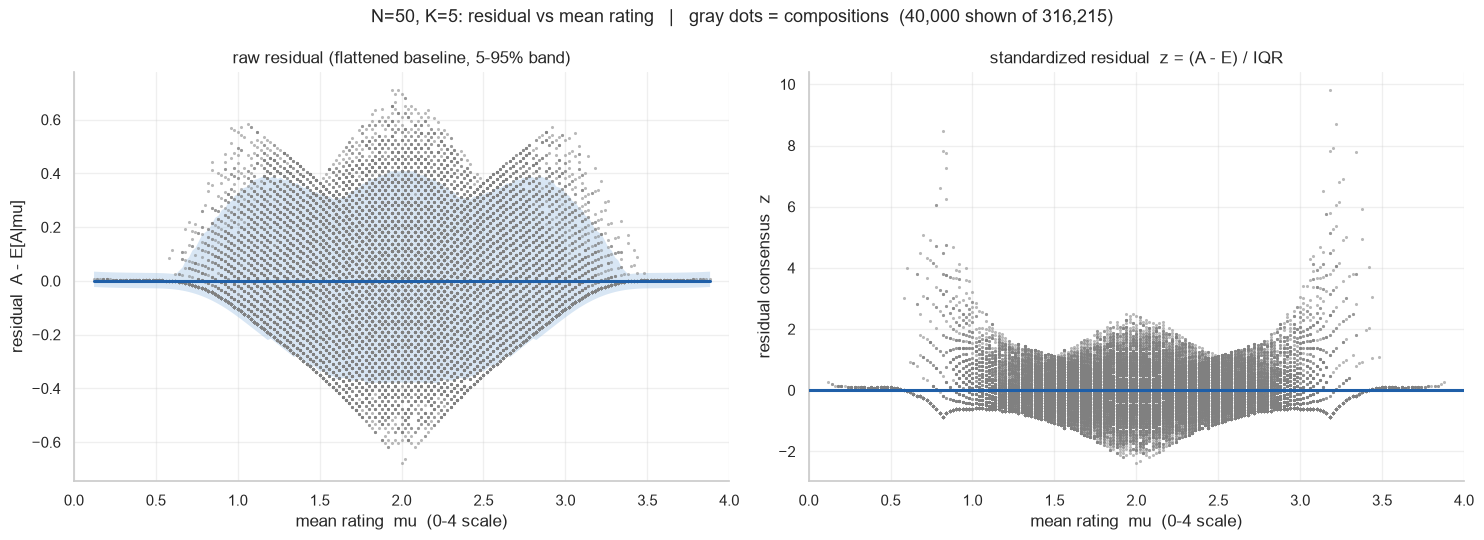

In [22]:
df, base = get_residual_df(50, 5)
STUDY[(50, 5)] = (df, base)
SUMMARY.append(summarize(df, 50, 5))
band_figure(df, base, 50, 5)

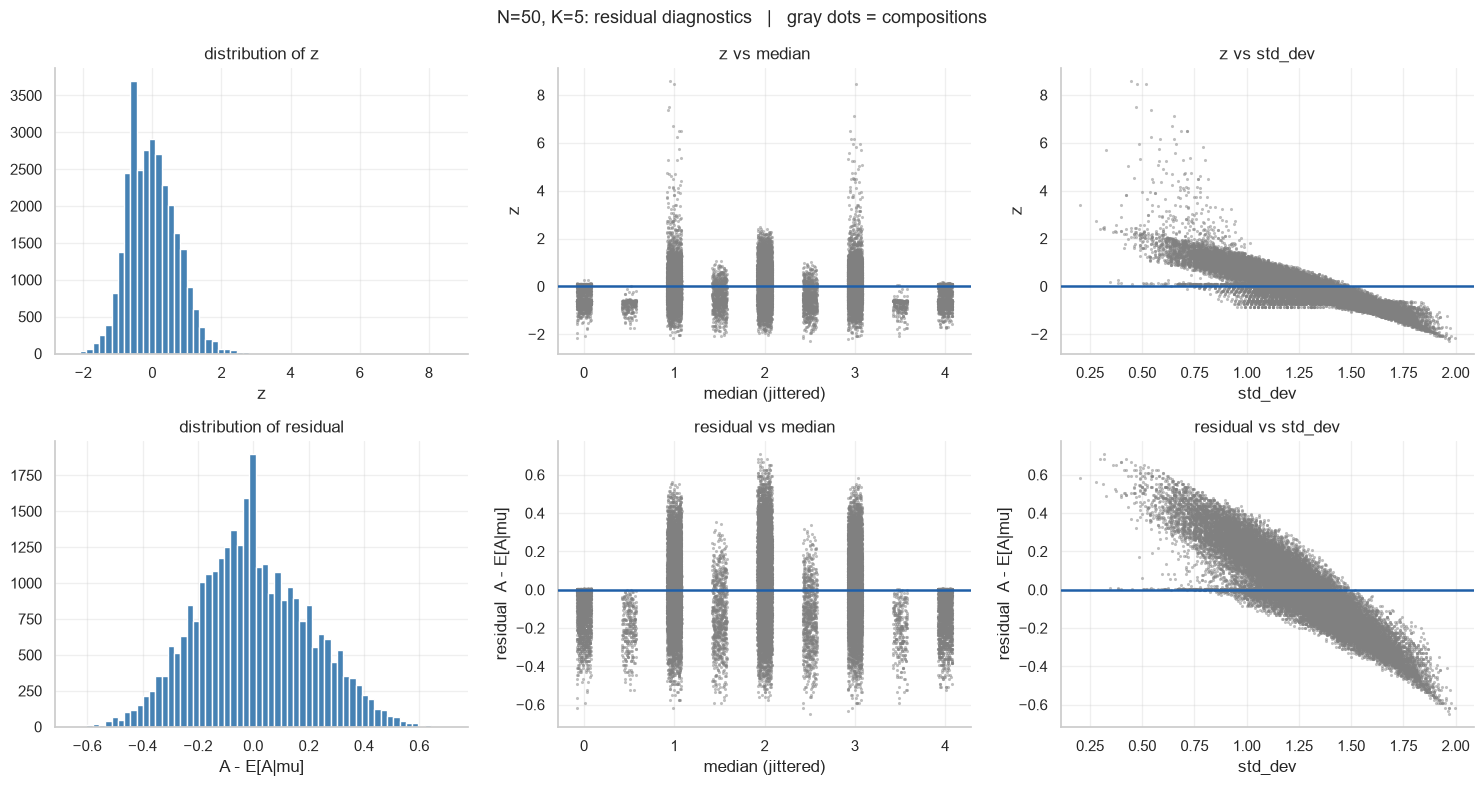

In [23]:
diagnostics_figure(df, 50, 5)

### N=50, K=6

N=50, K=6: Monte-Carlo 400,000 draws (exact cloud = 3,478,761 > ENUM_CAP)  (0.5s)  defined: 100.0%


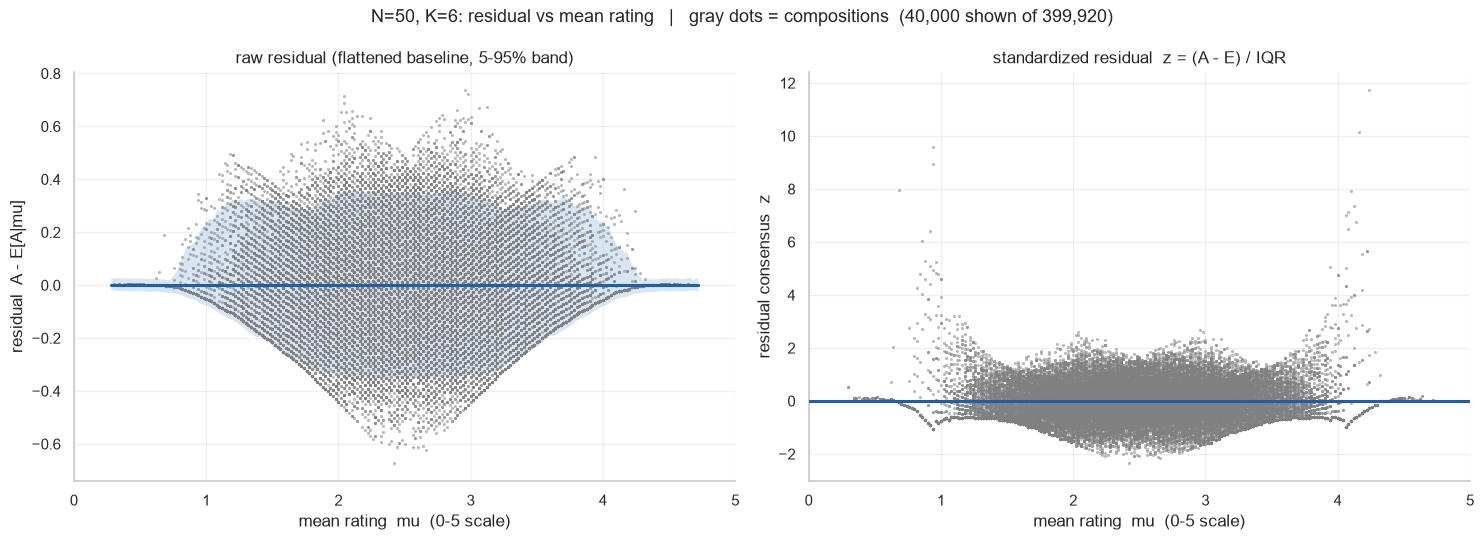

In [24]:
df, base = get_residual_df(50, 6)
STUDY[(50, 6)] = (df, base)
SUMMARY.append(summarize(df, 50, 6))
band_figure(df, base, 50, 6)

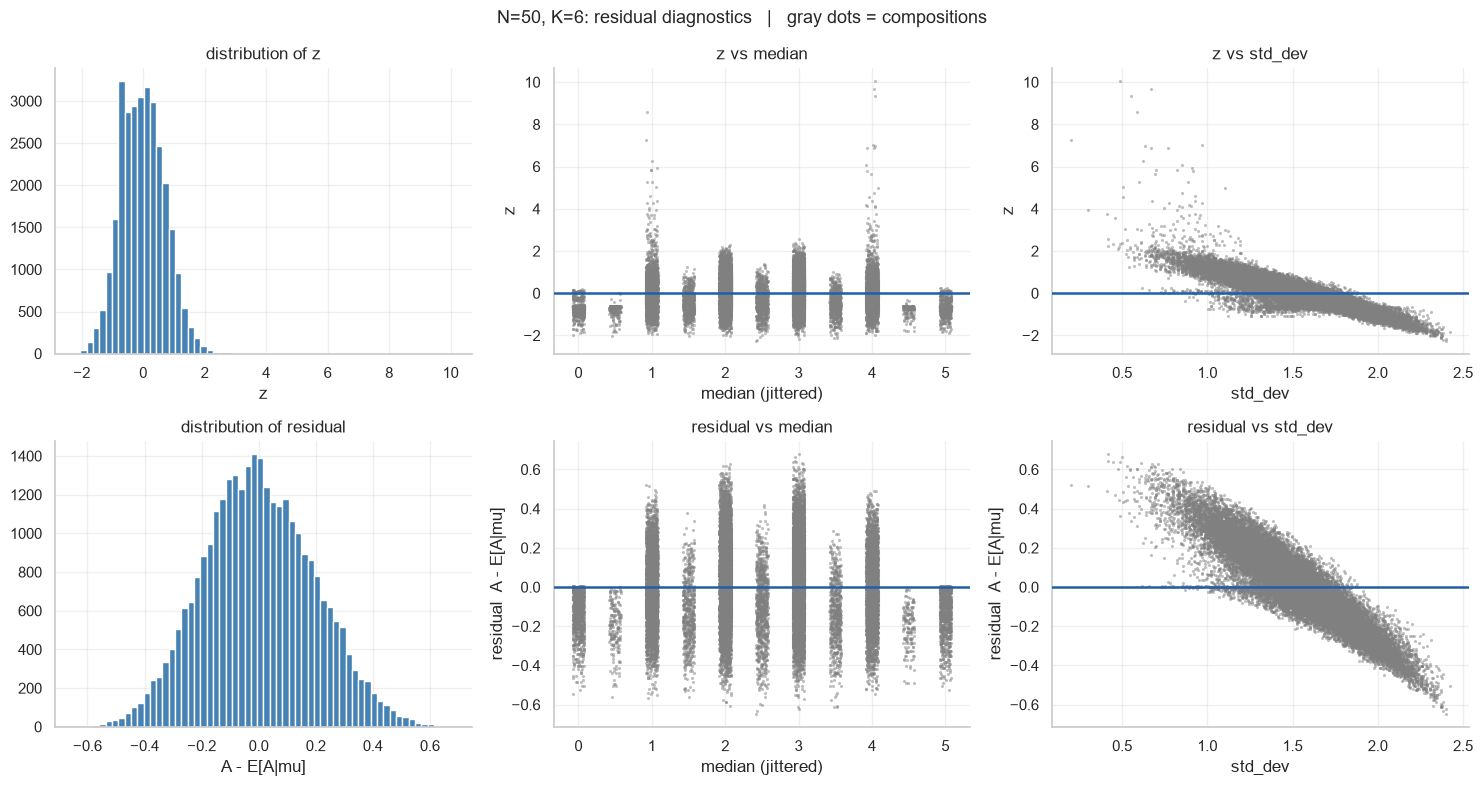

In [25]:
diagnostics_figure(df, 50, 6)

### N=50, K=7

N=50, K=7: Monte-Carlo 400,000 draws (exact cloud = 32,468,436 > ENUM_CAP)  (0.6s)  defined: 100.0%


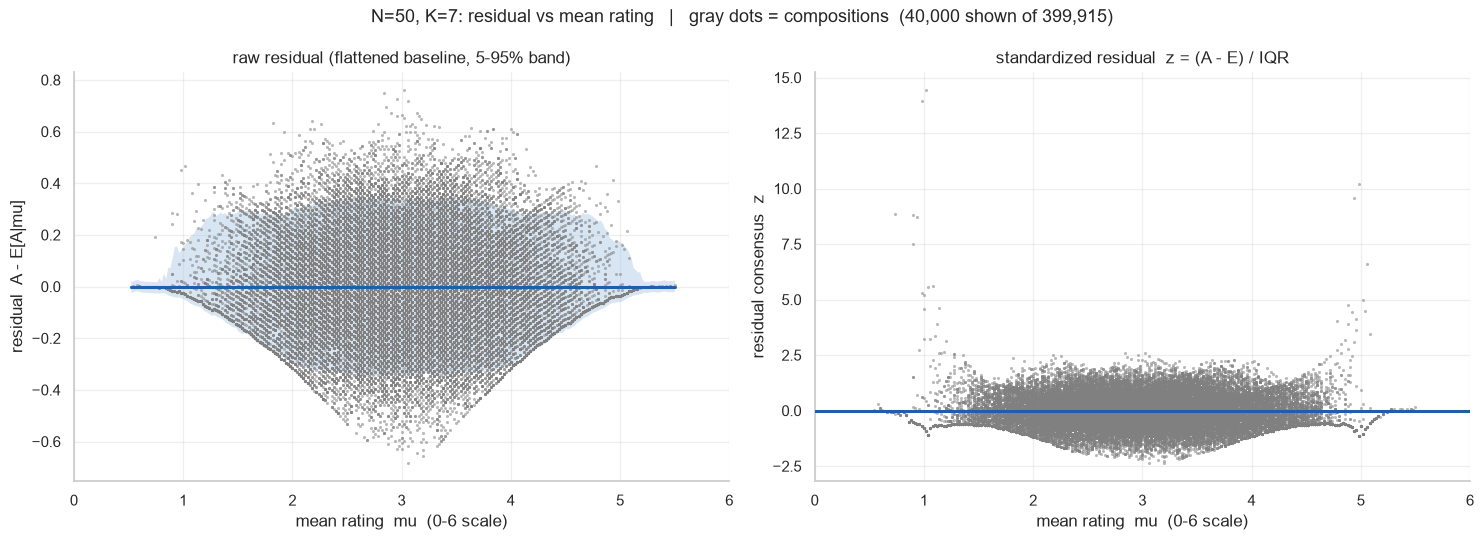

In [26]:
df, base = get_residual_df(50, 7)
STUDY[(50, 7)] = (df, base)
SUMMARY.append(summarize(df, 50, 7))
band_figure(df, base, 50, 7)

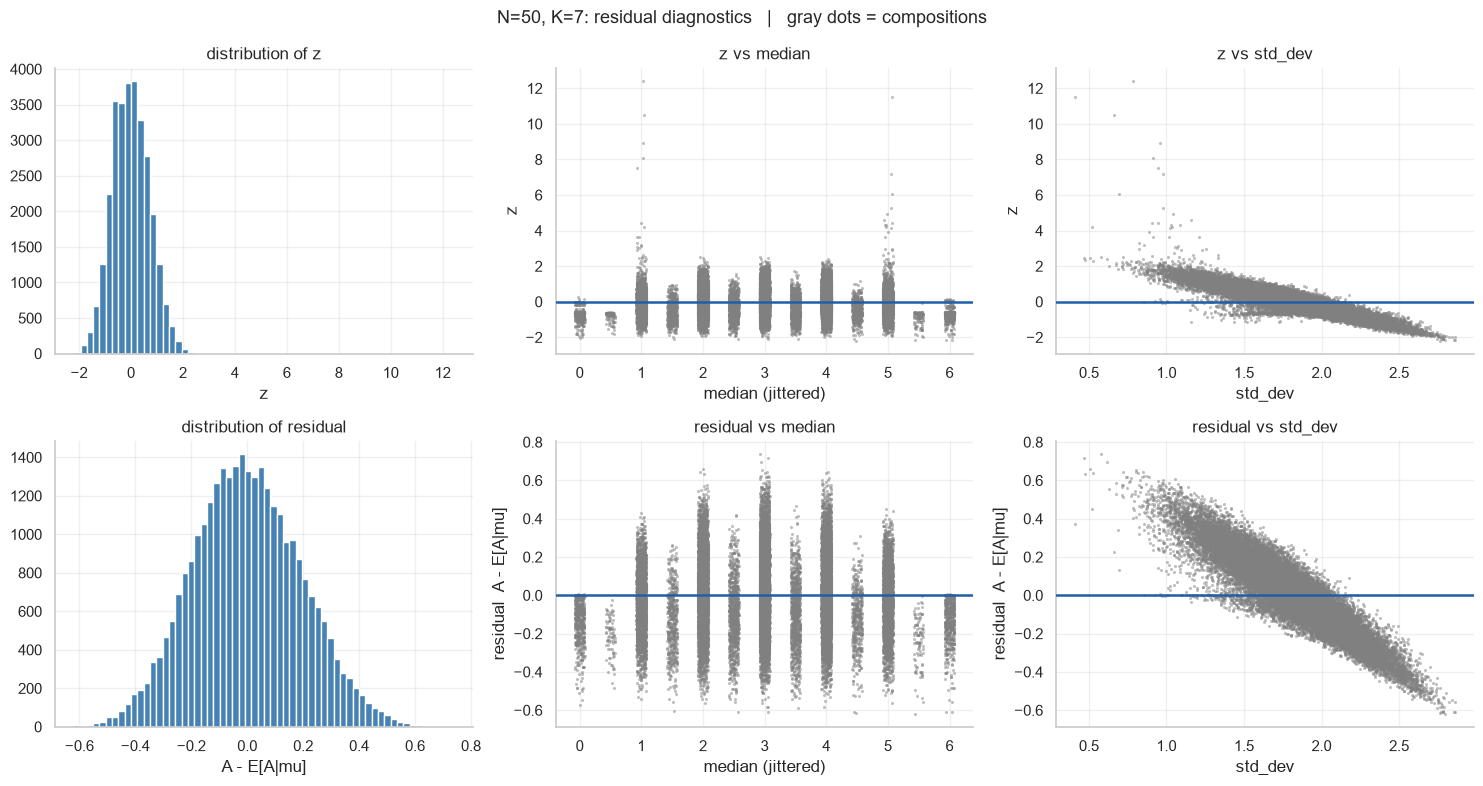

In [27]:
diagnostics_figure(df, 50, 7)

### N=70, K=4

N=70, K=4: exact enumeration, 62,196 compositions  (0.1s)  defined: 99.9%


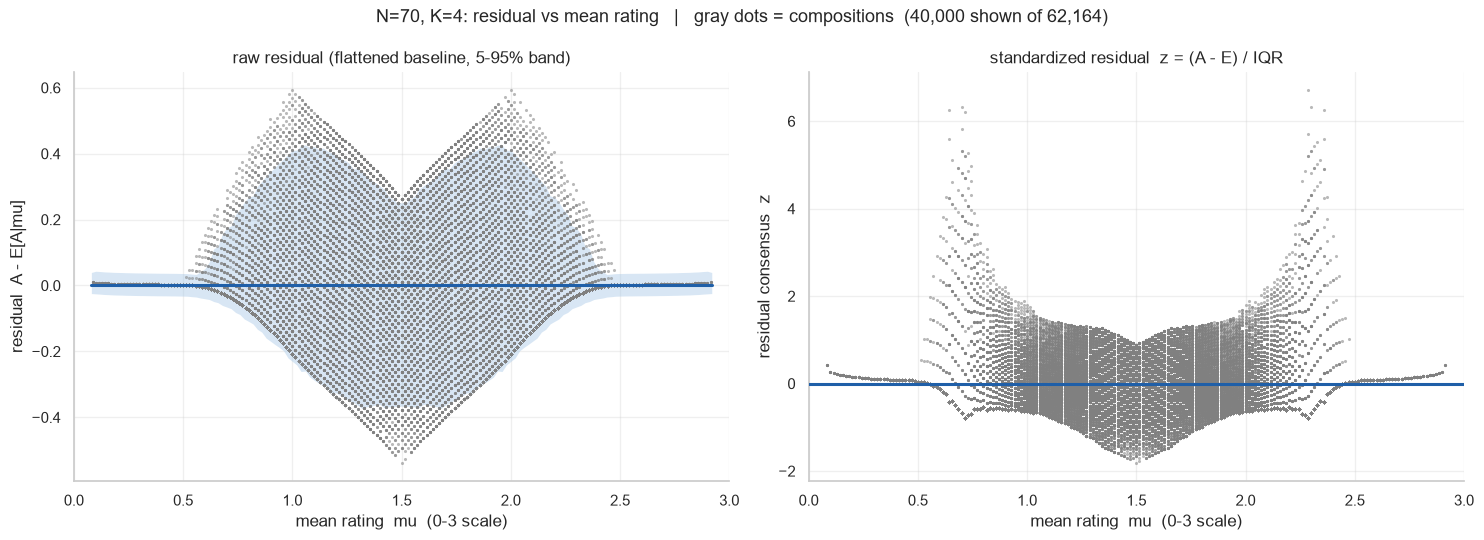

In [28]:
df, base = get_residual_df(70, 4)
STUDY[(70, 4)] = (df, base)
SUMMARY.append(summarize(df, 70, 4))
band_figure(df, base, 70, 4)

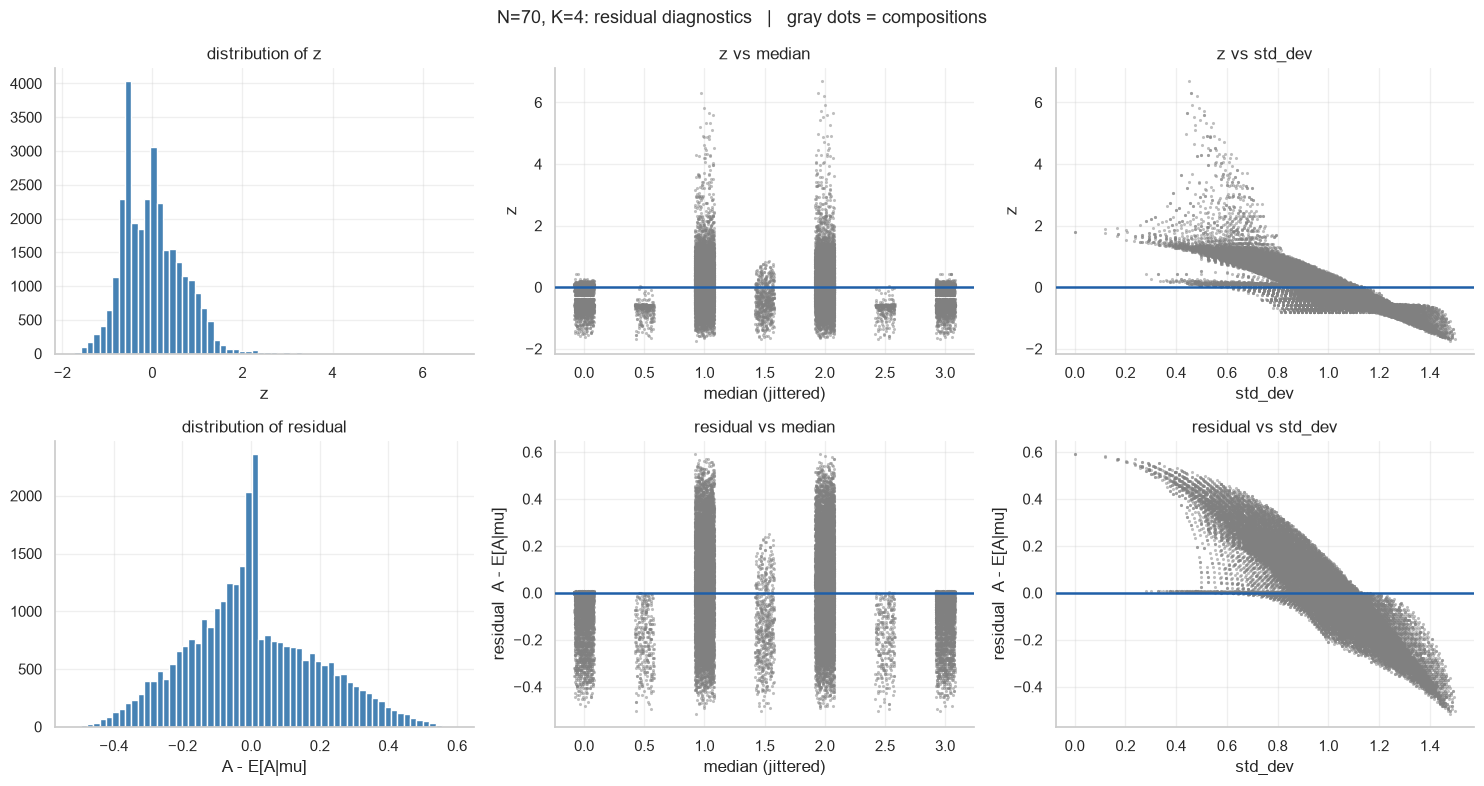

In [29]:
diagnostics_figure(df, 70, 4)

### N=70, K=5

N=70, K=5: Monte-Carlo 400,000 draws (exact cloud = 1,150,626 > ENUM_CAP)  (0.5s)  defined: 100.0%


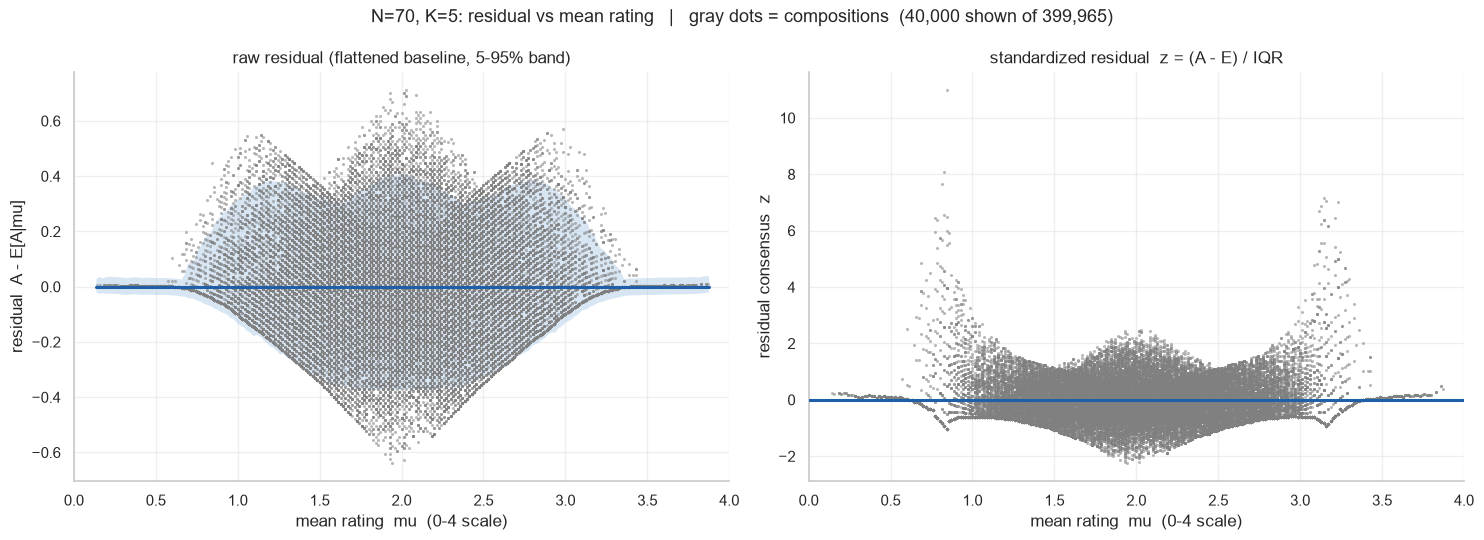

In [30]:
df, base = get_residual_df(70, 5)
STUDY[(70, 5)] = (df, base)
SUMMARY.append(summarize(df, 70, 5))
band_figure(df, base, 70, 5)

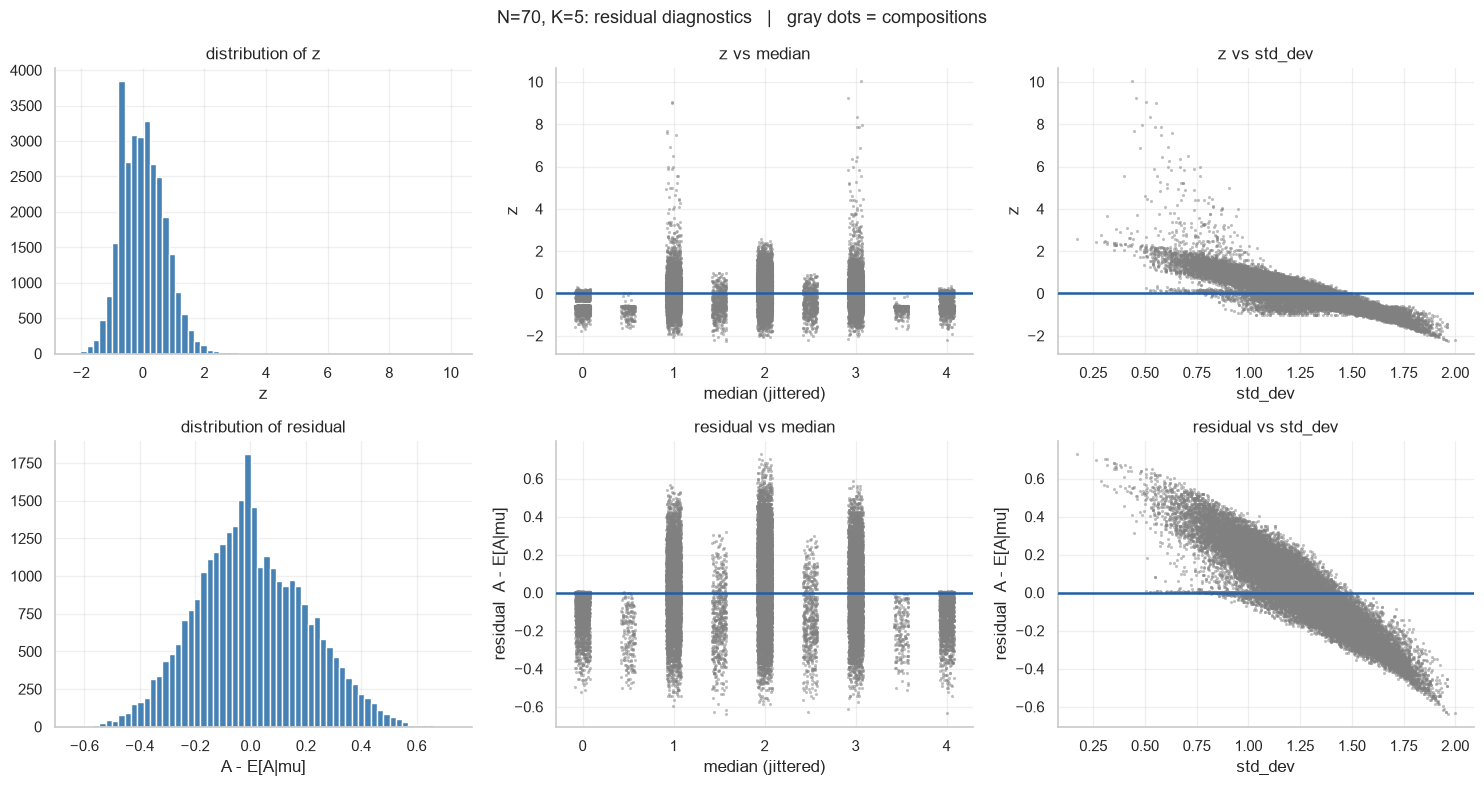

In [31]:
diagnostics_figure(df, 70, 5)

### N=70, K=6

N=70, K=6: Monte-Carlo 400,000 draws (exact cloud = 17,259,390 > ENUM_CAP)  (0.5s)  defined: 100.0%


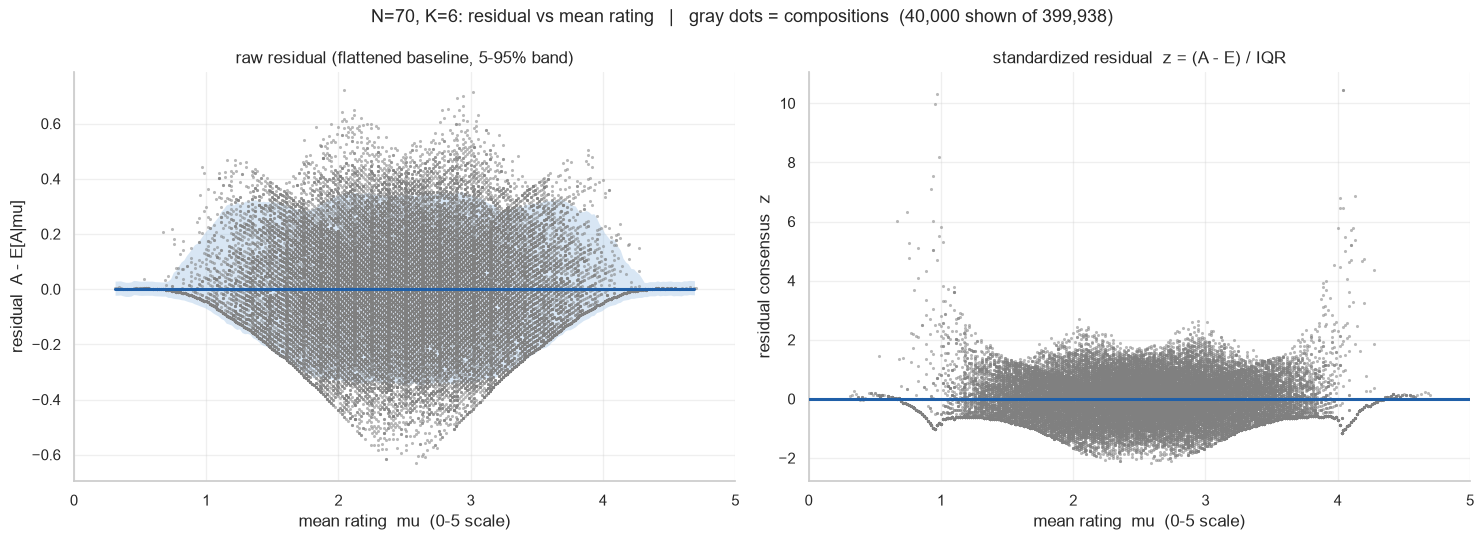

In [32]:
df, base = get_residual_df(70, 6)
STUDY[(70, 6)] = (df, base)
SUMMARY.append(summarize(df, 70, 6))
band_figure(df, base, 70, 6)

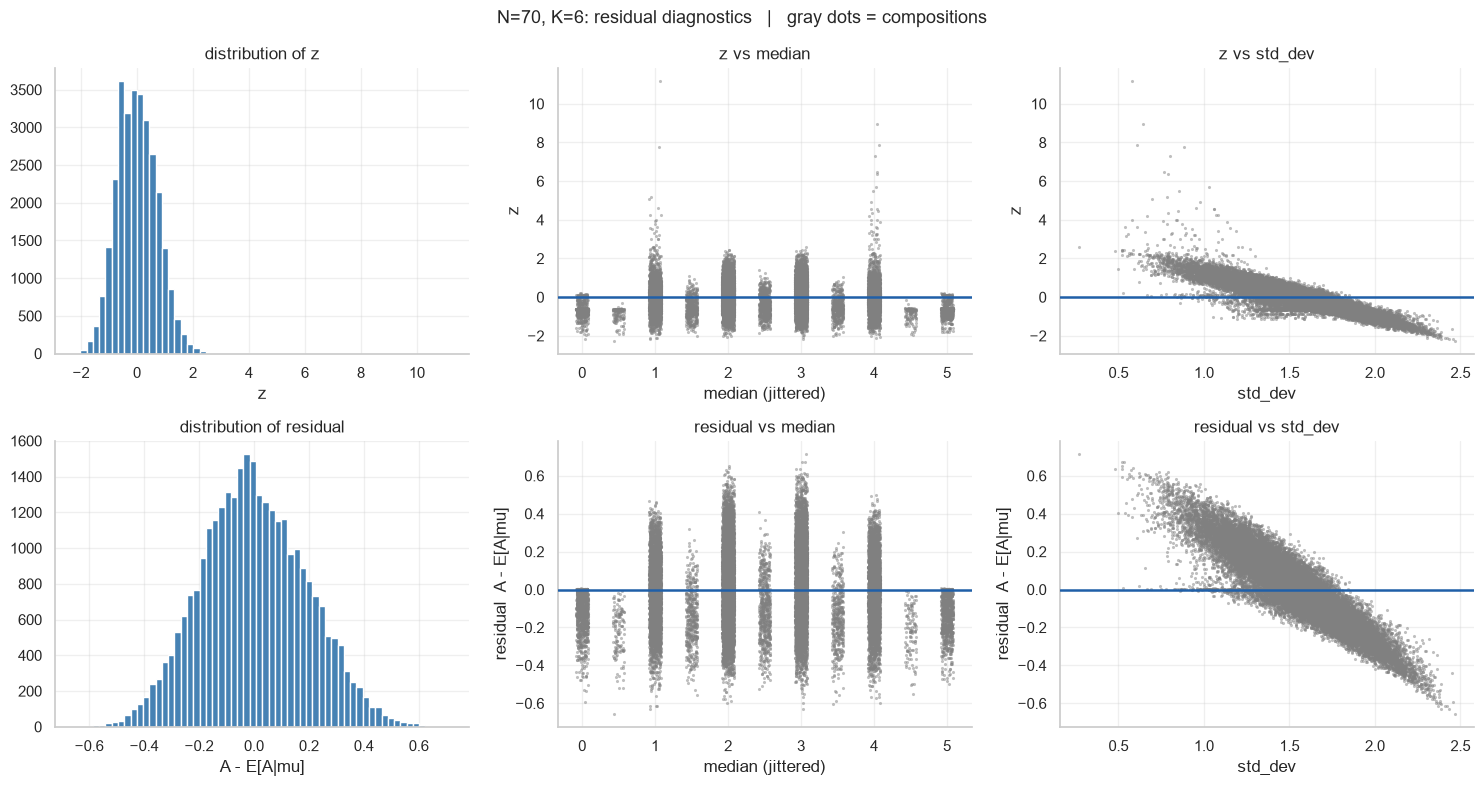

In [33]:
diagnostics_figure(df, 70, 6)

### N=70, K=7

N=70, K=7: Monte-Carlo 400,000 draws (exact cloud = 218,618,940 > ENUM_CAP)  (0.5s)  defined: 100.0%


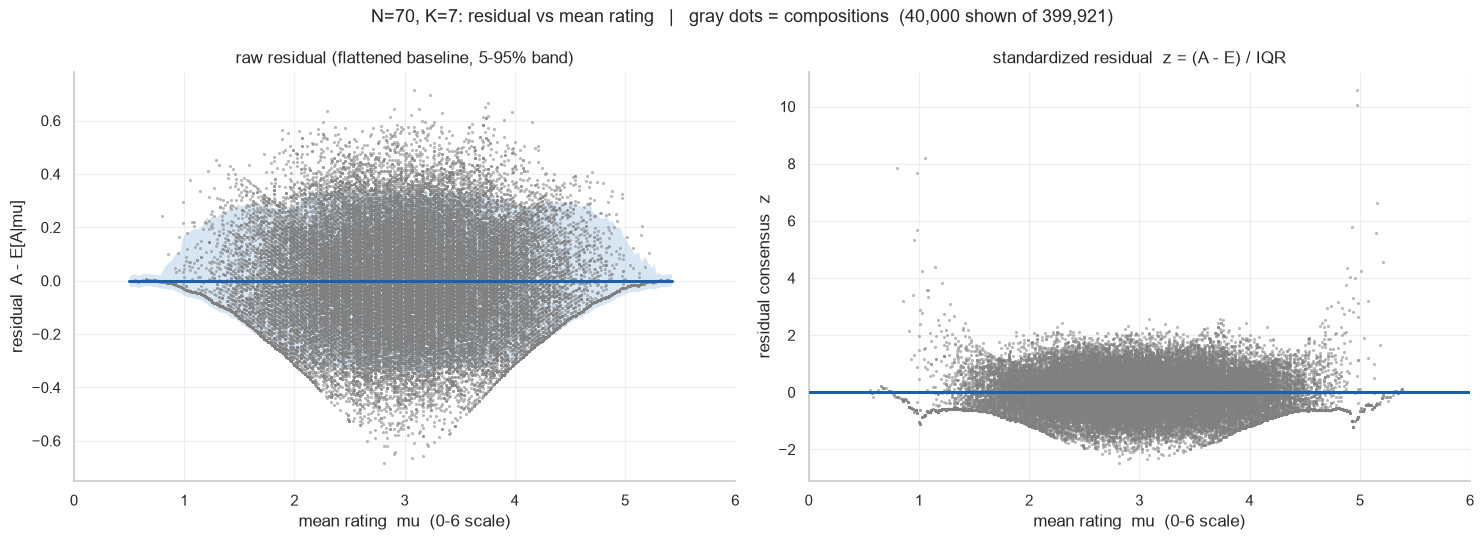

In [34]:
df, base = get_residual_df(70, 7)
STUDY[(70, 7)] = (df, base)
SUMMARY.append(summarize(df, 70, 7))
band_figure(df, base, 70, 7)

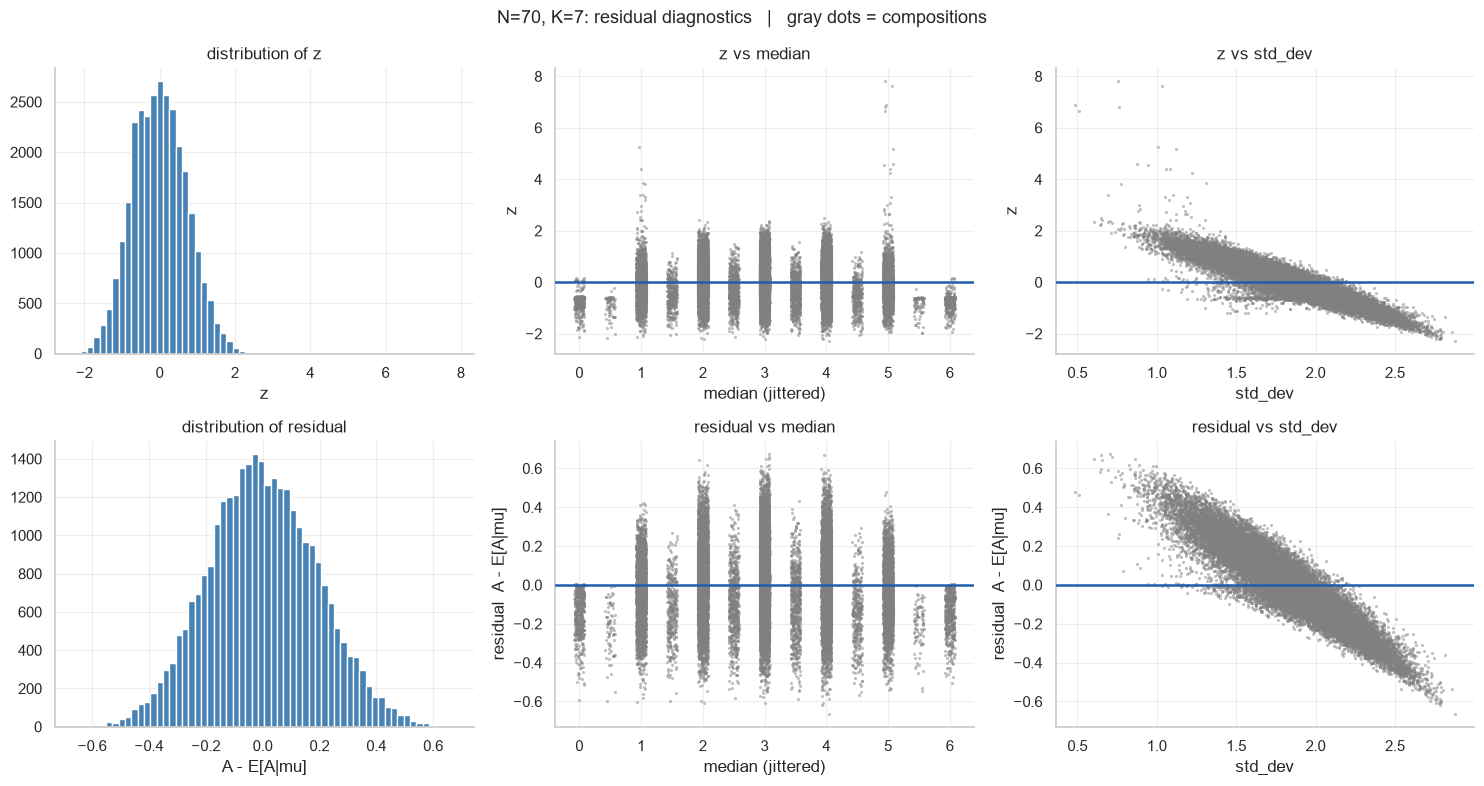

In [35]:
diagnostics_figure(df, 70, 7)

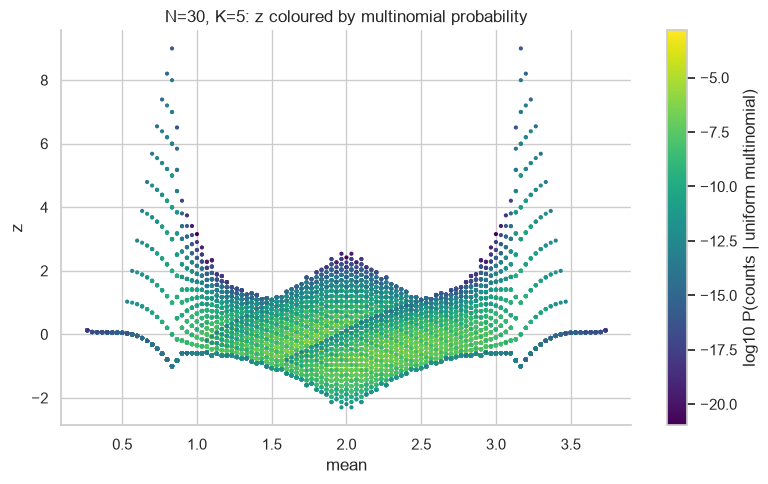

In [36]:
n, k = 30, 5
C = enumerate_compositions_fast(n, k)
df, _ = STUDY[(n, k)]
logp = (gammaln(n + 1) - gammaln(C + 1).sum(axis=1)) / np.log(10) - n * np.log10(k)
d = df.assign(log10_prob=logp)[df["defined"]]
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(d["mean"], d["z"], c=d["log10_prob"], s=4, cmap="viridis")
fig.colorbar(sc, label="log10 P(counts | uniform multinomial)")
ax.set(xlabel="mean", ylabel="z", title=f"N={n}, K={k}: z coloured by multinomial probability")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [37]:
def z_for_counts(C, n, k, base):
    A, mean = rc._A_vec(C, k)
    EQ = np.array([base.get(m, (np.nan,) * 4) for m in np.round(mean, 2)])
    E, _, _, IQR = EQ.T
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(np.isfinite(IQR) & (IQR > rc.EPS), (A - E) / IQR, np.nan), mean

rows = []
for (n, k) in [(20, 5), (30, 5), (50, 5), (70, 5)]:
    _, base = STUDY[(n, k)]
    draws = RNG.multinomial(n, np.ones(k) / k, size=8000)
    z, mean = z_for_counts(draws, n, k, base)
    z = z[np.isfinite(z)]
    rows.append({"N": n, "K": k, "draws_defined": len(z),
                 "median(z)": round(np.median(z), 3),
                 "IQR(z)": round(np.percentile(z, 75) - np.percentile(z, 25), 3),
                 "P(|z|>1.5)": round(float((np.abs(z) > 1.5).mean()), 3)})
pd.DataFrame(rows)

,N,K,draws_defined,median(z),IQR(z),P(|z|>1.5)
0,20,5,8000,-0.277,0.489,0.001
1,30,5,8000,-0.299,0.383,0.000
2,50,5,8000,-0.355,0.347,0.000
3,70,5,8000,-0.356,0.294,0.000


**Interpretation.** Multinomial(uniform) draws land consistently a bit *below*
the composition-cloud expectation (median z ≈ −0.3) with a spread well under 1
that tightens as N grows. This is not a bug: the module's baseline (uniform over
compositions, i.e. Dirichlet(1,…,1) proportions) is a *feasibility* reference,
not a *sampling* null. Consequences: (a) z values should be compared against
each other or against an empirical distribution of units, not read as
"standard deviations under random responding"; (b) if a sampling null is the
intended reference, `feasible_baseline` could instead weight compositions by
their multinomial probability (Section 2's `log10_prob` column is exactly that
weight).

N=18, K=5: exact enumeration, 7,315 compositions  (0.0s)  defined: 93.4%
N=25, K=5: exact enumeration, 23,751 compositions  (0.0s)  defined: 99.7%
N=40, K=5: exact enumeration, 135,751 compositions  (0.1s)  defined: 100.0%


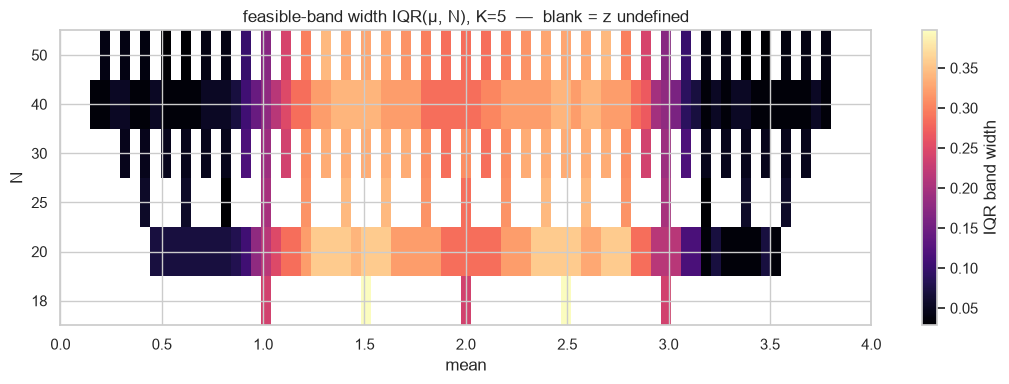

In [38]:
ns = [18, 20, 25, 30, 40, 50]
k = 5
grid_mu = np.round(np.arange(0.0, 4.001, 0.05), 2)
M = np.full((len(ns), len(grid_mu)), np.nan)
for i, n in enumerate(ns):
    if (n, k) in STUDY:
        base = STUDY[(n, k)][1]
    else:
        dfn, base = get_residual_df(n, k)
    for j, m in enumerate(grid_mu):
        if m in base:
            M[i, j] = base[m][3]
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(M, aspect="auto", origin="lower", cmap="magma",
               extent=[grid_mu[0], grid_mu[-1], -0.5, len(ns) - 0.5])
ax.set_yticks(range(len(ns)), labels=[str(n) for n in ns])
ax.set(xlabel="mean", ylabel="N", title=f"feasible-band width IQR(μ, N), K={k}  —  blank = z undefined")
fig.colorbar(im, label="IQR band width")
plt.tight_layout()

In [39]:
def pick_unit(df, mu0, z0, label=""):
    '''Nearest defined composition in the cloud to a target (mu, z).'''
    d = df[df["defined"]]
    w = 0.03
    cand = d[np.abs(d["mean"] - mu0) <= w]
    while len(cand) == 0:
        w *= 2
        cand = d[np.abs(d["mean"] - mu0) <= w]
    row = cand.iloc[(cand["z"] - z0).abs().to_numpy().argmin()]
    return {"label": label, "A": float(row["Agreement"]),
            **{c: float(row[c]) for c in ["mean", "E", "z"]}}

In [40]:
def worked_examples_figure(df, anatomy, anatomy_title, trio, n, k, encoding="raw"):
    '''The standard worked-examples summary figure.
       encoding="raw"      -> y = consensus A (curved baseline)
       encoding="residual" -> y = A - E[A|mu] (flattened baseline)
       anatomy / trio units: dicts with label, mean, A, E, z (trio ordered
       above, as-expected, below).'''
    grid, E, lo, hi = quantile_band(df)
    Efun = lambda m: np.interp(m, grid, E)
    if encoding == "raw":
        y = lambda u: u["A"]; yE = lambda u: u["E"]
        centre, b_lo, b_hi = E, lo, hi
        ylim, ylab = (-0.15, 1.0), "consensus  A"
        head, ysc = "RAW-A encoding (y = consensus A, curved baseline)", "y -0.15 to 1.0"
        t1, t2 = (0.55, 0.83), (1.15, 0.30)              # annotation text spots
        leg_y = (0.93, 0.86, 0.79)                        # trio text block (top)
    else:
        y = lambda u: u["A"] - u["E"]; yE = lambda u: 0.0
        centre, b_lo, b_hi = np.zeros_like(E), lo - E, hi - E
        ylim, ylab = (-0.4, 0.3), "residual  A - E[A|mu]"
        head, ysc = "RESIDUAL encoding (y = A - E, flattened baseline)", "y -0.4 to 0.3"
        t1, t2 = (0.55, 0.10), (1.15, -0.05)
        leg_y = (0.24, 0.16, 0.08)                        # trio text block (bottom)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f"Worked examples - {head}   |   "
                 f"uniform scales: x 0-{k-1}, {ysc}, band n={n}", fontsize=13)
    for ax in axes:
        ax.fill_between(grid, b_lo, b_hi, color=BAND_C, alpha=0.55, lw=0)
        ax.plot(grid, centre, color=BLUE, lw=2.5)
        ax.set(xlim=(0, k - 1), ylim=ylim,
               xlabel=f"mean rating  mu  (0-{k-1} scale)", ylabel=ylab)
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    # ---- left: anatomy of one unit -------------------------------------
    ax = axes[0]
    u = anatomy
    ax.plot([u["mean"]], [yE(u)], "o", color=BLUE, ms=7, zorder=5)
    ax.plot([u["mean"]], [y(u)], "v", color=RED, ms=11, mec="#7a2a12", zorder=5)
    ax.plot([u["mean"]] * 2, [yE(u), y(u)], ls="--", color=RED, lw=1)
    ax.annotate(f"E[A|mu] = {u['E']:.3f}", xy=(u["mean"], yE(u)), xytext=t1,
                color=BLUE, fontsize=11,
                arrowprops=dict(arrowstyle="->", color=BLUE, lw=1))
    ax.annotate(f"A = {u['A']:.3f}", xy=(u["mean"], y(u)), xytext=t2,
                color=RED, fontsize=11,
                arrowprops=dict(arrowstyle="->", color=RED, lw=1))
    ax.text(u["mean"] + 0.10, y(u), f"z = {u['z']:+.2f}",
            color="#7a2a12", fontsize=12, fontweight="bold", va="center")
    ax.set_title(f"Anatomy - {anatomy_title}")

    # ---- right: same mean, different residual ---------------------------
    ax = axes[1]
    up, mid, dn = trio
    ax.plot([mid["mean"], up["mean"]], [y(mid), y(up)],
            ls="--", color=GREEN, lw=1.4, zorder=4)
    ax.plot([up["mean"]], [y(up)], "^", color=GREEN, ms=12, mec="#0e5232", zorder=5)
    ax.plot([mid["mean"]], [y(mid)], "o", color="#9a9a9a", ms=10, mec="#555555", zorder=5)
    ax.plot([dn["mean"]], [y(dn)], "v", color=RED, ms=11, mec="#7a2a12", zorder=5)
    for (name, u_, col), fy in zip(
            [("above", up, GREEN), ("as expected", mid, GREY), ("below", dn, RED)], leg_y):
        ax.text(0.04, fy, f"{name}: {u_['label']}  z={u_['z']:+.2f}",
                transform=ax.transAxes, color=col, fontsize=11)
    mus = sorted(u_["mean"] for u_ in trio)
    ax.set_title(f"Same mean (mu~{mus[0]:.2f}-{mus[-1]:.2f}), different residual")
    plt.tight_layout()

N=25, K=5: exact enumeration, 23,751 compositions  (0.0s)  defined: 99.7%
257861 Communication     mu=3.200  A=0.429  E=0.470  z=-1.46
179214 Availabili        mu=3.160  A=0.657  E=0.454  z=+3.56
174457 Communicat        mu=3.240  A=0.486  E=0.488  z=-0.03
255626 Communicat        mu=3.200  A=0.429  E=0.470  z=-1.46


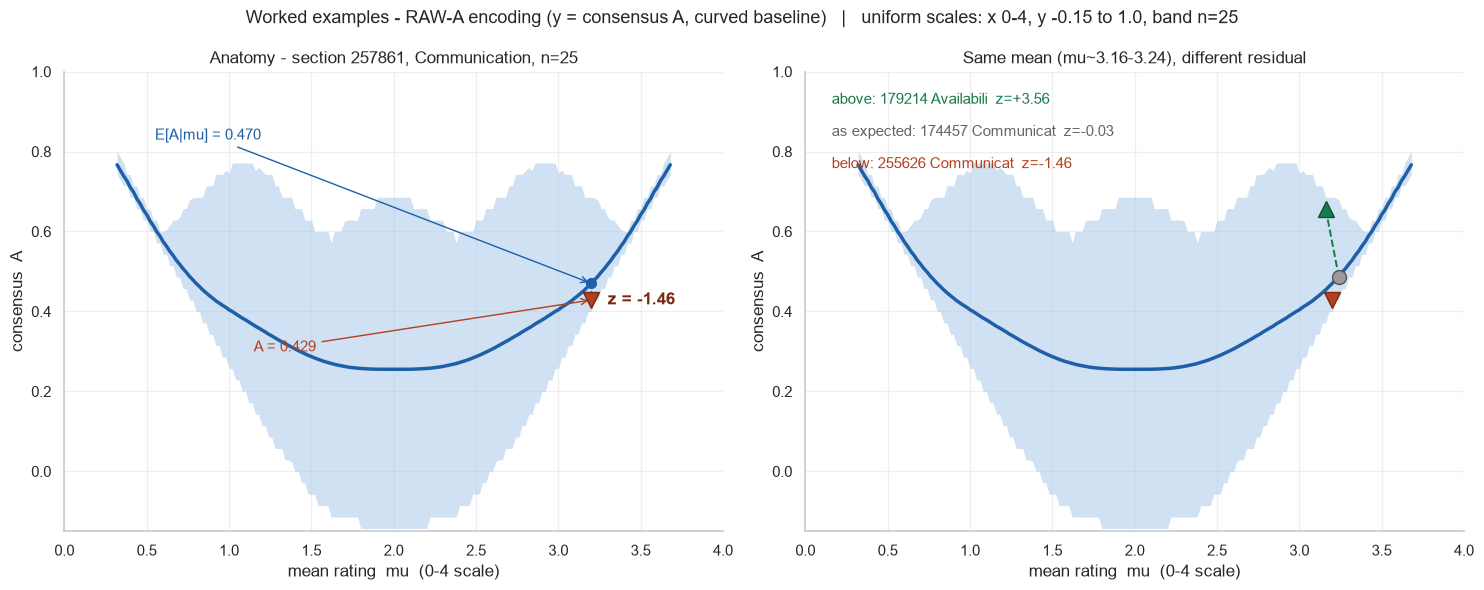

In [41]:
df25, base25 = get_residual_df(25, 5)
STUDY[(25, 5)] = (df25, base25)

anatomy = pick_unit(df25, 3.20, -1.46, "257861 Communication")
trio = [pick_unit(df25, 3.16, +3.56, "179214 Availabili"),
        pick_unit(df25, 3.24, +0.09, "174457 Communicat"),
        pick_unit(df25, 3.20, -1.72, "255626 Communicat")]
for u in [anatomy] + trio:
    print(f"{u['label']:24s} mu={u['mean']:.3f}  A={u['A']:.3f}  "
          f"E={u['E']:.3f}  z={u['z']:+.2f}")

worked_examples_figure(df25, anatomy, "section 257861, Communication, n=25",
                       trio, n=25, k=5, encoding="raw")

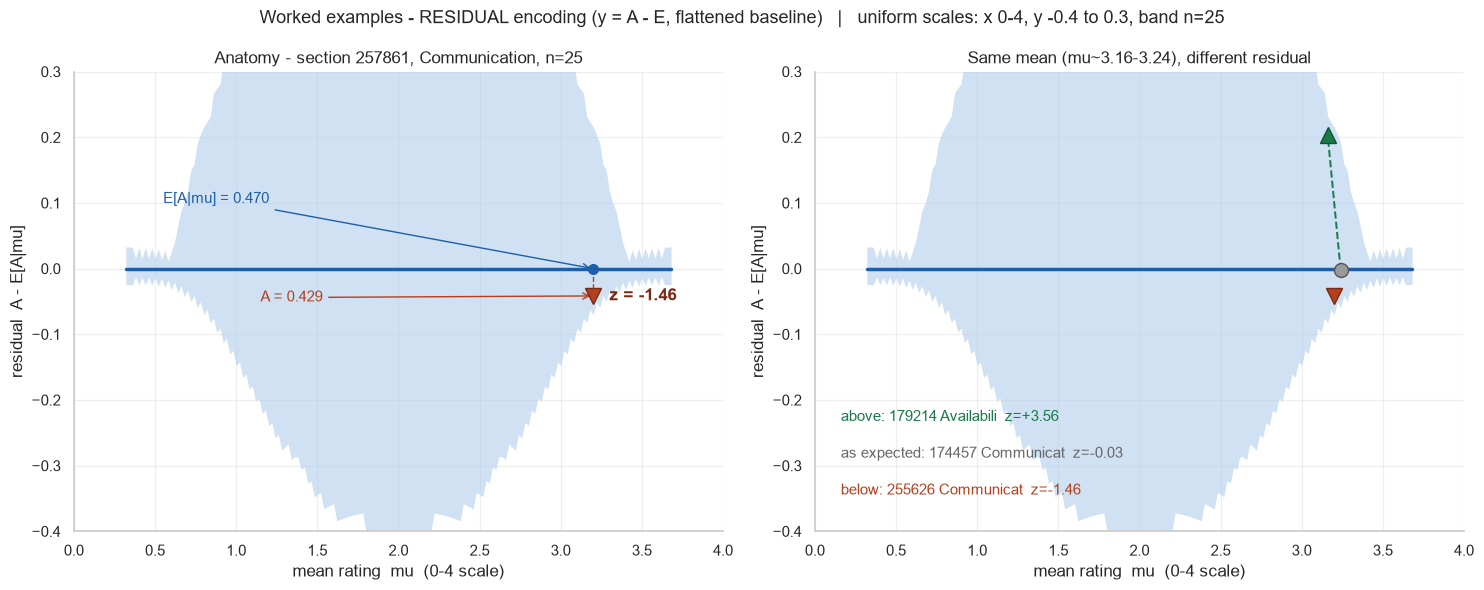

In [42]:
worked_examples_figure(df25, anatomy, "section 257861, Communication, n=25",
                       trio, n=25, k=5, encoding="residual")

## Summary across all (N, K)

In [43]:
summary = pd.DataFrame(SUMMARY)
summary

,N,K,cloud_size,pct_defined,"corr(mean, A)","corr(mean, z)",median(z),IQR(z)
0,20,4,1771,93.1,-0.015,0.002,-0.087,1.052
1,20,5,10626,99.0,0.000,-0.002,-0.060,1.046
2,20,6,53130,99.8,-0.000,-0.002,-0.038,1.018
3,20,7,230230,100.0,-0.000,-0.000,-0.036,1.032
4,30,4,5456,98.1,0.000,0.000,-0.072,1.000
5,30,5,46376,99.8,-0.000,-0.000,-0.051,1.029
6,30,6,324632,100.0,0.000,0.000,-0.037,1.048
7,30,7,400000,100.0,-0.000,0.000,-0.022,1.034
8,50,4,23426,99.8,-0.000,-0.000,-0.050,0.968
9,50,5,316251,100.0,0.000,-0.000,-0.061,1.041
